# OV7675 Image Viewer

In [1]:
# Import the needed libraries
from matplotlib import pyplot as plt
import numpy as np
import struct

In [2]:
# Copy the output of the Serial Monitor to the variable below
HEXADECIMAL_BYTES = [
0xBC, 0xBD, 0xB9, 0xB5, 0xB3, 0xB3, 0xAF, 0xA4, 0x9E, 0x9D, 0xA0, 0xA9, 0xA9, 0x74, 0x56, 0x96,
0xA9, 0xA9, 0xA7, 0xA6, 0xA5, 0xA0, 0x9F, 0x9A, 0x96, 0x94, 0x92, 0x90, 0x89, 0x8B, 0x8A, 0x8B,
0x8A, 0x86, 0x80, 0x83, 0x80, 0x80, 0x80, 0x7C, 0x7C, 0x7C, 0x76, 0x72, 0x6D, 0x5F, 0x41, 0x3D,
0x36, 0x3B, 0x4C, 0x5C, 0x59, 0x57, 0x5A, 0x47, 0x3C, 0x4C, 0x48, 0x45, 0x40, 0x4B, 0x4D, 0x4E,
0x50, 0x50, 0x44, 0x3C, 0x37, 0x50, 0x67, 0x95, 0xC0, 0x86, 0x7C, 0x4A, 0x3C, 0x4B, 0x50, 0x59,
0x63, 0x66, 0x68, 0x6D, 0x70, 0x6E, 0x67, 0x61, 0x58, 0x5C, 0x5E, 0x67, 0x63, 0x64, 0x7C, 0x87,
0xBA, 0xB8, 0xB9, 0xB8, 0xB4, 0xB0, 0xA8, 0xA2, 0xA0, 0x9F, 0xA8, 0xAC, 0xBB, 0x49, 0x46, 0xA8,
0xA8, 0xA8, 0xA7, 0xA6, 0xA2, 0x9F, 0x9B, 0x96, 0x8E, 0x8E, 0x8C, 0x88, 0x88, 0x88, 0x75, 0x81,
0x8F, 0x82, 0x73, 0x62, 0x68, 0x6E, 0x6B, 0x6A, 0x5E, 0x5B, 0x5F, 0x5B, 0x41, 0x2C, 0x34, 0x2C,
0x52, 0x59, 0x68, 0x59, 0x5C, 0x61, 0x4E, 0x48, 0x3D, 0x24, 0x38, 0x44, 0x5F, 0x4C, 0x36, 0x34,
0x3D, 0x52, 0x48, 0x43, 0x33, 0x32, 0x5C, 0x72, 0x56, 0xF8, 0xBC, 0x3A, 0xAF, 0x99, 0x8F, 0x80,
0x70, 0x64, 0x42, 0x48, 0x4E, 0x5B, 0x3C, 0x5C, 0x59, 0x4A, 0x67, 0x9B, 0xB7, 0x9F, 0x92, 0x9A,
0xBA, 0xBA, 0xB8, 0xB6, 0xB3, 0xAD, 0xA7, 0xA2, 0x9F, 0xA2, 0xAA, 0xAC, 0xC2, 0x3B, 0x76, 0xA1,
0xA6, 0xA6, 0xA7, 0xA5, 0xA1, 0x9C, 0x97, 0x93, 0x8C, 0x8C, 0x84, 0x82, 0x7E, 0x78, 0x81, 0x80,
0x8B, 0x89, 0x7D, 0x7E, 0x7F, 0x7B, 0x7B, 0x78, 0x76, 0x78, 0x7B, 0x73, 0x6D, 0x6D, 0x63, 0x7D,
0x68, 0x57, 0x5D, 0x64, 0x5B, 0x4A, 0x3C, 0x3A, 0x41, 0x3E, 0x40, 0x43, 0x58, 0x6A, 0x52, 0x4A,
0x35, 0x42, 0x35, 0x51, 0x5D, 0x5C, 0x5B, 0x5E, 0x62, 0x5A, 0x53, 0x7F, 0x8A, 0x67, 0x66, 0x63,
0x6D, 0x7E, 0x81, 0x71, 0x75, 0x73, 0x69, 0x5F, 0x60, 0x5A, 0x73, 0x7F, 0x75, 0x60, 0x4D, 0x53,
0xBA, 0xB9, 0xB7, 0xB3, 0xB2, 0xAD, 0xA3, 0xA0, 0x9F, 0xA6, 0xAC, 0xAE, 0xA4, 0x57, 0xA2, 0xA2,
0xA7, 0xA6, 0xAA, 0xA5, 0xA5, 0x9A, 0x94, 0x8C, 0x81, 0x7F, 0x78, 0x72, 0x77, 0x80, 0x80, 0x81,
0x7D, 0x7C, 0x89, 0x86, 0x8A, 0x87, 0x87, 0x82, 0x86, 0x78, 0x75, 0x7B, 0x7B, 0x72, 0x72, 0x73,
0x72, 0x72, 0x70, 0x77, 0x79, 0x7D, 0x83, 0x80, 0x8A, 0x64, 0x3C, 0xA9, 0x73, 0x86, 0x47, 0x3F,
0x4F, 0x4D, 0x4B, 0x63, 0x24, 0x37, 0x42, 0x55, 0x8D, 0xA2, 0x5C, 0x16, 0x49, 0x6F, 0x81, 0x83,
0x8A, 0x87, 0x7A, 0x69, 0x55, 0x51, 0x43, 0x4A, 0x47, 0x5C, 0x5A, 0x53, 0x52, 0x47, 0x3C, 0x2F,
0xBA, 0xB9, 0xB4, 0xB2, 0xAF, 0xA8, 0xA1, 0xA0, 0xA0, 0xA7, 0xAF, 0xAE, 0x7F, 0x42, 0xB5, 0x9F,
0xA1, 0xA4, 0xA0, 0x9D, 0x9B, 0x97, 0x91, 0x8A, 0x7E, 0x73, 0x73, 0x5C, 0x53, 0x53, 0x51, 0x4F,
0x57, 0x54, 0x50, 0x57, 0x30, 0x50, 0x57, 0x4F, 0x49, 0x4E, 0x46, 0x4B, 0x4D, 0x46, 0x45, 0x4D,
0x4C, 0x52, 0x4F, 0x4E, 0x5B, 0x56, 0x62, 0x80, 0x85, 0x49, 0x68, 0x63, 0x83, 0x7E, 0x86, 0x83,
0x5D, 0x47, 0x67, 0x52, 0x6F, 0x2D, 0x36, 0x49, 0x4A, 0x7E, 0x83, 0x28, 0x3C, 0x72, 0x75, 0x85,
0x9B, 0x83, 0x76, 0x70, 0x66, 0x61, 0x59, 0x5F, 0x6C, 0x7C, 0x85, 0x8C, 0x92, 0x8E, 0x91, 0x6D,
0xB9, 0xB6, 0xB4, 0xB1, 0xAC, 0xA7, 0xA2, 0xA1, 0xA3, 0xAA, 0xAE, 0xAE, 0x47, 0x32, 0xA7, 0x9C,
0x96, 0x9C, 0x9D, 0x9B, 0x97, 0x8F, 0x85, 0x8E, 0x7B, 0x66, 0x3D, 0x50, 0x48, 0x52, 0x52, 0x51,
0x4A, 0x4E, 0x4F, 0x4C, 0x4B, 0x4B, 0x4E, 0x3B, 0x4D, 0x4A, 0x48, 0x49, 0x4A, 0x44, 0x45, 0x45,
0x45, 0x46, 0x49, 0x46, 0x4A, 0x48, 0x46, 0x43, 0x4A, 0x5C, 0x59, 0x48, 0x43, 0x46, 0x6A, 0x89,
0x89, 0x8C, 0x5F, 0x57, 0x5F, 0x3C, 0x3B, 0x41, 0x47, 0x30, 0xAD, 0x79, 0x27, 0x67, 0x6A, 0x70,
0x72, 0x72, 0x7E, 0x92, 0x8C, 0x6A, 0x4E, 0x5D, 0x65, 0x80, 0x8E, 0x94, 0x97, 0x99, 0x99, 0x98,
0xB8, 0xB5, 0xB2, 0xB0, 0xA9, 0xA4, 0xA2, 0xA2, 0xA4, 0xA9, 0xAA, 0xB3, 0x56, 0x2A, 0x9A, 0x97,
0x93, 0x95, 0xA8, 0xA8, 0x86, 0x70, 0x67, 0x68, 0x30, 0x4B, 0x3A, 0x4E, 0x4C, 0x4F, 0x50, 0x4D,
0x52, 0x4F, 0x51, 0x53, 0x4E, 0x4C, 0x41, 0x52, 0x4D, 0x4A, 0x4A, 0x46, 0x4A, 0x48, 0x49, 0x48,
0x49, 0x4B, 0x4F, 0x48, 0x4D, 0x46, 0x45, 0x41, 0x47, 0x47, 0x51, 0x4D, 0x45, 0x46, 0x4E, 0x54,
0x5C, 0x92, 0xA0, 0x6D, 0x57, 0x60, 0x3F, 0x48, 0x3D, 0x3E, 0x21, 0x78, 0xD2, 0x77, 0x66, 0x6F,
0x70, 0x6D, 0x73, 0x73, 0x64, 0x64, 0xA0, 0xB7, 0xB3, 0x92, 0x92, 0x96, 0x9F, 0x9D, 0x9E, 0x9D,
0xB6, 0xB2, 0xAE, 0xAD, 0xA6, 0xA3, 0xA1, 0xA1, 0xA4, 0xA7, 0xA6, 0xAC, 0x46, 0x36, 0x90, 0x92,
0x8E, 0x73, 0x50, 0x3F, 0x42, 0x5D, 0x6B, 0x51, 0x4A, 0x4D, 0x48, 0x46, 0x4C, 0x4E, 0x34, 0x78,
0x77, 0x70, 0x72, 0x56, 0x4F, 0x4C, 0x32, 0x73, 0x6C, 0x77, 0x5F, 0x5E, 0x51, 0x49, 0x44, 0x3A,
0x47, 0x3F, 0x2B, 0x38, 0x3C, 0x37, 0x3F, 0x44, 0x4A, 0x4E, 0x33, 0x3D, 0x4C, 0x48, 0x4B, 0x66,
0x61, 0x6D, 0x84, 0xA5, 0x69, 0x60, 0x3B, 0x34, 0x67, 0x74, 0x50, 0x4A, 0x45, 0xC1, 0xC0, 0x66,
0x45, 0x5C, 0x71, 0x70, 0x69, 0x55, 0x55, 0x66, 0x77, 0x7E, 0x81, 0x89, 0x88, 0x91, 0x9F, 0xA7,
0xB3, 0xB0, 0xAB, 0xAA, 0xA4, 0xA1, 0xA0, 0xA1, 0xA3, 0xA5, 0xA4, 0xAA, 0x54, 0x36, 0x80, 0x78,
0x6F, 0x54, 0x49, 0x61, 0x68, 0x68, 0x45, 0x44, 0x45, 0x48, 0x4E, 0x4E, 0x47, 0x4F, 0x55, 0x51,
0x24, 0x38, 0x2C, 0x3C, 0x25, 0x4A, 0xA2, 0x9F, 0x58, 0x9F, 0xBF, 0x83, 0x9E, 0x87, 0xAD, 0xB3,
0xAB, 0x6F, 0xBB, 0xDD, 0xA0, 0x8D, 0x3A, 0x38, 0xFB, 0xE4, 0xE4, 0x9E, 0x4B, 0x53, 0x51, 0x70,
0x6F, 0x6C, 0x72, 0x7A, 0xA4, 0x83, 0x2C, 0x33, 0x72, 0x6A, 0x82, 0x35, 0x40, 0x48, 0x43, 0x90,
0xE1, 0xEE, 0xD2, 0xB1, 0x86, 0x5D, 0x58, 0x68, 0x7E, 0x82, 0x88, 0x81, 0x7E, 0x79, 0x6E, 0x6A,
0xB1, 0xAE, 0xA8, 0xA5, 0xA4, 0xA3, 0xA0, 0xA0, 0xA3, 0xA4, 0xA1, 0xA2, 0x73, 0x2F, 0x78, 0x7A,
0x5A, 0x59, 0x5E, 0x5F, 0x56, 0x48, 0x5A, 0x3C, 0x45, 0x49, 0x48, 0x51, 0x4C, 0x4A, 0x3D, 0x40,
0x47, 0x40, 0x3E, 0x42, 0xA2, 0x5C, 0x30, 0x21, 0x57, 0x66, 0x4A, 0x7E, 0x88, 0x68, 0xA0, 0x94,
0x52, 0xAA, 0x5D, 0x54, 0x4C, 0x41, 0x45, 0x63, 0x58, 0x57, 0x4B, 0x99, 0x51, 0x58, 0x58, 0x57,
0x6E, 0x72, 0x76, 0x75, 0x89, 0xB7, 0x29, 0x2E, 0x75, 0x69, 0x69, 0x29, 0x3C, 0x46, 0x43, 0x3E,
0x34, 0x34, 0x63, 0x73, 0x85, 0x7B, 0x88, 0x8D, 0x7B, 0x79, 0x79, 0x6C, 0x66, 0x69, 0x6E, 0x6A,
0xAD, 0xAB, 0xAB, 0xA5, 0xA2, 0xA1, 0xA0, 0x9E, 0x9F, 0x9F, 0x9E, 0x9A, 0x9B, 0x4F, 0x77, 0x77,
0x83, 0x60, 0x4B, 0x39, 0x47, 0x2C, 0x38, 0x40, 0x44, 0x46, 0x3A, 0x4F, 0x4C, 0x5A, 0x57, 0x5F,
0x50, 0x4E, 0x4C, 0x53, 0x5A, 0x55, 0x5B, 0x74, 0x37, 0x29, 0x6E, 0xA1, 0x57, 0x88, 0xAA, 0x70,
0x60, 0x47, 0x41, 0x3D, 0x44, 0x46, 0x67, 0x55, 0x5E, 0x5C, 0x5F, 0x5A, 0x70, 0x60, 0x58, 0x58,
0x5B, 0x82, 0x92, 0x89, 0x8E, 0x86, 0xCA, 0x1C, 0x79, 0x71, 0x69, 0x32, 0x3A, 0x33, 0x39, 0x53,
0x34, 0x4C, 0x46, 0x4F, 0x57, 0x53, 0x55, 0x59, 0x56, 0x4D, 0x4E, 0x4B, 0x4E, 0x3F, 0x49, 0x41,
0xA9, 0xA8, 0xA7, 0xA4, 0xA1, 0x9D, 0x9F, 0x9E, 0x9D, 0x9D, 0x9C, 0x97, 0x9E, 0x51, 0x4D, 0x70,
0x77, 0x85, 0x91, 0x5F, 0x46, 0x4A, 0x45, 0x45, 0x46, 0x41, 0x49, 0x43, 0x49, 0x4E, 0x54, 0x40,
0x4B, 0x50, 0x46, 0x4E, 0x4F, 0x54, 0x57, 0x50, 0x4D, 0x56, 0x74, 0x40, 0xEB, 0xF0, 0xF8, 0x5B,
0x51, 0x42, 0x41, 0x44, 0x47, 0x45, 0x28, 0x61, 0x26, 0x3F, 0x67, 0x43, 0x42, 0x47, 0x42, 0x41,
0x53, 0x59, 0x94, 0x9A, 0x9C, 0x94, 0x8F, 0x94, 0x74, 0x6F, 0x6A, 0x3D, 0x3B, 0x2F, 0x36, 0x38,
0x4D, 0x56, 0x48, 0x4C, 0x42, 0x48, 0x44, 0x4C, 0x4E, 0x50, 0x56, 0x44, 0x27, 0x43, 0x55, 0x43,
0xA8, 0xA7, 0xA7, 0xA2, 0xA1, 0x9F, 0x9D, 0x9E, 0x9D, 0x9B, 0x96, 0x95, 0x95, 0x4F, 0x4A, 0x7F,
0x71, 0x6E, 0x6C, 0x71, 0x4B, 0x36, 0x43, 0x38, 0x41, 0x3F, 0x48, 0x49, 0x49, 0x43, 0x49, 0x48,
0x50, 0x45, 0x3E, 0x51, 0x59, 0x52, 0x3E, 0x3E, 0x4C, 0x4E, 0x7E, 0x5E, 0x48, 0x4A, 0x4E, 0x63,
0x73, 0x44, 0x3F, 0x33, 0x4D, 0x65, 0x39, 0x62, 0xFF, 0xA0, 0xD3, 0xA6, 0xE5, 0xF5, 0xEE, 0xED,
0x5E, 0x44, 0x8D, 0x8F, 0x94, 0x90, 0x89, 0x9C, 0x22, 0x6D, 0x6B, 0x60, 0x2F, 0x26, 0x28, 0x3B,
0x3E, 0x3C, 0x56, 0x56, 0x50, 0x5F, 0x55, 0x36, 0x46, 0x31, 0x30, 0x30, 0x42, 0x40, 0x23, 0x3B,
0xA8, 0xA4, 0xA4, 0xA3, 0xA2, 0x9F, 0x9C, 0x9C, 0x9A, 0x98, 0x98, 0x98, 0x95, 0xB8, 0x2E, 0x54,
0x35, 0x7A, 0x75, 0x6C, 0x72, 0x7E, 0x6C, 0x46, 0x3E, 0x5F, 0x4C, 0x3A, 0x2E, 0x3E, 0x4C, 0x4B,
0x50, 0x52, 0x4A, 0x54, 0x4F, 0x41, 0x56, 0x48, 0x4A, 0x42, 0x6D, 0x63, 0x5C, 0x58, 0x6A, 0x82,
0x66, 0x40, 0x4E, 0x3E, 0x33, 0x80, 0x3A, 0x7F, 0x42, 0x5C, 0x6C, 0x68, 0x73, 0x65, 0x73, 0x7F,
0x56, 0x5A, 0x91, 0x8C, 0x8C, 0x95, 0x8A, 0x9E, 0x77, 0x53, 0x54, 0x80, 0x30, 0x3B, 0x2E, 0x3A,
0x39, 0x3E, 0x46, 0x52, 0x4E, 0x6A, 0x8F, 0x8D, 0x8E, 0x8D, 0x8A, 0x91, 0x7E, 0x2C, 0x20, 0x3F,
0xA5, 0xA2, 0xA2, 0xA1, 0x9F, 0x9D, 0x9D, 0x9B, 0x9A, 0x98, 0x99, 0x98, 0x97, 0x95, 0x77, 0x3E,
0x3E, 0x61, 0x4B, 0x62, 0x6B, 0x66, 0x74, 0x9C, 0x53, 0x46, 0x41, 0x43, 0x3F, 0x78, 0x85, 0x87,
0x5A, 0x47, 0x47, 0x54, 0x4B, 0x50, 0x4A, 0x49, 0x4D, 0x46, 0x96, 0x91, 0x5F, 0x66, 0x5E, 0x4C,
0x44, 0x35, 0x74, 0x52, 0x4A, 0x4D, 0x37, 0x71, 0x5F, 0x57, 0xFC, 0xC9, 0xC3, 0xFB, 0x5D, 0x5A,
0x4F, 0x58, 0x8C, 0x85, 0x87, 0x84, 0x83, 0x8C, 0x77, 0x7E, 0x72, 0x32, 0x37, 0x42, 0x50, 0x5A,
0x44, 0x3B, 0x2B, 0x5D, 0x64, 0x8A, 0x91, 0x92, 0x91, 0x92, 0x91, 0x8F, 0x91, 0x95, 0x9C, 0xB5,
0xA4, 0xA0, 0xA1, 0x9F, 0x9F, 0x9F, 0x9D, 0x9B, 0x9C, 0x9C, 0x9A, 0x96, 0x97, 0x94, 0x67, 0x40,
0x41, 0x37, 0x54, 0x59, 0x3A, 0x3E, 0x56, 0x6C, 0x81, 0x85, 0x4D, 0x40, 0x4C, 0x47, 0x53, 0x59,
0x6B, 0x55, 0x55, 0x60, 0x4E, 0x49, 0x64, 0x4C, 0x4D, 0x30, 0xC4, 0x71, 0xBC, 0xB9, 0x29, 0x49,
0x52, 0x4B, 0x3E, 0x56, 0x41, 0x31, 0x39, 0x5F, 0x5D, 0x5E, 0x66, 0x75, 0x5A, 0x57, 0x5D, 0x5D,
0x5E, 0x47, 0x85, 0x88, 0x89, 0x85, 0x7D, 0x91, 0x80, 0x7B, 0x7E, 0x8A, 0x36, 0x3C, 0x39, 0x75,
0x5A, 0x58, 0x49, 0x3D, 0x5F, 0x85, 0xA0, 0x97, 0x96, 0x99, 0x9B, 0x98, 0x97, 0x97, 0x98, 0x9F,
0xA3, 0xA0, 0x9E, 0x9F, 0x9E, 0x9E, 0x9D, 0x9D, 0x9A, 0x9B, 0x9A, 0x99, 0x98, 0x98, 0xA3, 0x42,
0x50, 0x40, 0x3E, 0x54, 0x47, 0x4C, 0x45, 0x75, 0x4C, 0x77, 0xA5, 0x8B, 0x27, 0x48, 0x68, 0x47,
0x6B, 0x67, 0x52, 0x93, 0x92, 0x32, 0x1A, 0x30, 0x37, 0xEC, 0x98, 0x5F, 0x97, 0x1D, 0x3F, 0x47,
0x77, 0x66, 0x35, 0x3C, 0x40, 0x3F, 0x7D, 0x81, 0xA6, 0x98, 0xAB, 0xB1, 0x47, 0x5C, 0x5E, 0x5B,
0x5A, 0x4D, 0x85, 0x88, 0x85, 0x7E, 0x7C, 0x94, 0x58, 0x67, 0x7C, 0x7A, 0x7C, 0x39, 0x3C, 0x43,
0x4C, 0x5D, 0x63, 0x47, 0x48, 0x93, 0xA3, 0x9C, 0x9F, 0xA4, 0xA4, 0xA4, 0xA3, 0xA3, 0x98, 0x9A,
0x9F, 0x9F, 0x9F, 0x9F, 0x9D, 0x9E, 0x9D, 0x9C, 0x9C, 0x9B, 0x9A, 0x99, 0x97, 0x98, 0x95, 0xA8,
0x64, 0x46, 0x3B, 0x5A, 0x45, 0x41, 0x45, 0x43, 0x48, 0x61, 0x6F, 0x7B, 0xA2, 0x6E, 0x53, 0x4C,
0x5C, 0x63, 0x51, 0xC5, 0xA9, 0xEB, 0xD4, 0xF0, 0xCC, 0xFF, 0x78, 0x5D, 0x3A, 0x51, 0x51, 0x55,
0x91, 0x8B, 0x70, 0x6B, 0x62, 0x96, 0x8D, 0x56, 0xAF, 0xAF, 0x7E, 0xBE, 0x41, 0x5D, 0x5E, 0x5C,
0x55, 0x52, 0x85, 0x88, 0x82, 0x89, 0x69, 0x9A, 0x85, 0x7E, 0x74, 0x57, 0x67, 0x3E, 0x40, 0x3E,
0x4E, 0x54, 0x66, 0x6D, 0x52, 0xB2, 0xAA, 0xA0, 0xA1, 0xA5, 0xA3, 0xA8, 0xA7, 0xA6, 0xA0, 0x9A,
0xA1, 0x9F, 0x9F, 0xA0, 0x9E, 0x9F, 0x9E, 0x9D, 0x9C, 0x9B, 0x9B, 0x99, 0x98, 0x99, 0x96, 0x95,
0xAD, 0x4B, 0x48, 0x69, 0x59, 0x4B, 0x3A, 0x46, 0x4A, 0x4E, 0x4F, 0x77, 0x7C, 0x8C, 0x9C, 0x5F,
0x66, 0x7A, 0x54, 0xD6, 0x82, 0x8F, 0xE8, 0x7B, 0xFF, 0x9D, 0x83, 0x48, 0x50, 0x61, 0x5F, 0x62,
0x97, 0x74, 0xA1, 0xD8, 0xB9, 0x9E, 0xA0, 0x59, 0x8C, 0xA2, 0x61, 0x9B, 0x50, 0x5F, 0x5E, 0x5E,
0x5E, 0x56, 0x86, 0x86, 0x86, 0x85, 0x74, 0x9D, 0x89, 0x86, 0x8D, 0x8C, 0x91, 0x33, 0x42, 0x3F,
0x56, 0x5D, 0x53, 0x67, 0x6F, 0x96, 0xB0, 0xA5, 0xA5, 0xA9, 0x9B, 0x84, 0x2D, 0x2A, 0x35, 0x3D,
0xA1, 0xA0, 0x9E, 0x9E, 0x9E, 0x9E, 0x9D, 0x9D, 0x9C, 0x9D, 0x99, 0x99, 0x99, 0x99, 0x96, 0x95,
0x92, 0x9D, 0x43, 0x5B, 0x4C, 0x47, 0x41, 0x45, 0x47, 0x50, 0x48, 0x55, 0x49, 0x74, 0x7F, 0x9F,
0xA9, 0x7B, 0x47, 0xF5, 0xC9, 0xC7, 0x92, 0xB4, 0x8C, 0x34, 0x33, 0x51, 0x57, 0x5C, 0x5F, 0x66,
0x93, 0x73, 0x68, 0x97, 0x9D, 0x8E, 0x9B, 0x62, 0x62, 0x72, 0x72, 0x7E, 0x67, 0x63, 0x5A, 0x61,
0x5A, 0x5B, 0x87, 0x85, 0x86, 0x84, 0x7B, 0x9C, 0x88, 0x86, 0x87, 0x86, 0x82, 0x80, 0x50, 0x3B,
0x56, 0x64, 0x62, 0x65, 0x74, 0x69, 0x49, 0x52, 0x42, 0x52, 0x46, 0x36, 0x2F, 0x3C, 0x34, 0x24,
0xA0, 0x9E, 0x9F, 0x9F, 0xA0, 0xA1, 0x9D, 0x9D, 0x9D, 0x9C, 0x9A, 0x9A, 0x98, 0x97, 0x95, 0x95,
0x93, 0x92, 0xAB, 0x60, 0x5F, 0x32, 0x54, 0x37, 0x4F, 0x53, 0x55, 0x53, 0x55, 0x6D, 0x71, 0x78,
0x87, 0xAC, 0x9F, 0x77, 0xDE, 0xF0, 0xF3, 0xF9, 0x1E, 0x3B, 0x57, 0x5C, 0x5E, 0x61, 0x62, 0x6A,
0x8D, 0x87, 0xD1, 0xCC, 0xE0, 0x89, 0x88, 0x64, 0x63, 0x73, 0x48, 0x37, 0x4E, 0x74, 0x65, 0x61,
0x61, 0x4D, 0x85, 0x85, 0x88, 0x88, 0x7B, 0x99, 0x8B, 0x88, 0x8D, 0x88, 0x85, 0x89, 0x2F, 0x45,
0x4D, 0x49, 0x60, 0x60, 0x7A, 0x78, 0x80, 0x8B, 0x8F, 0x84, 0x78, 0x75, 0x7B, 0x6A, 0x76, 0x97,
0xA2, 0xA0, 0xA0, 0x9F, 0x9F, 0x9F, 0x9F, 0x9E, 0x9C, 0x9A, 0x9A, 0x9A, 0x98, 0x98, 0x96, 0x95,
0xA8, 0xA9, 0x7F, 0x6A, 0x8B, 0x74, 0x86, 0x80, 0x80, 0x84, 0x7F, 0x88, 0x96, 0x97, 0x98, 0x98,
0x8A, 0x72, 0x95, 0xB1, 0xA4, 0x5E, 0x43, 0x49, 0x5B, 0x59, 0x5A, 0x5E, 0x5C, 0x60, 0x62, 0x60,
0x5F, 0x6A, 0x6F, 0x64, 0x6D, 0x6F, 0x62, 0x65, 0x6A, 0x45, 0x41, 0x43, 0x38, 0x39, 0x62, 0x5F,
0x61, 0x52, 0x86, 0x89, 0x88, 0x85, 0x89, 0x95, 0x8A, 0x89, 0x8A, 0x88, 0x83, 0x85, 0x72, 0x47,
0x49, 0x48, 0x50, 0x54, 0x74, 0x75, 0x77, 0x91, 0x93, 0x94, 0x92, 0x93, 0x92, 0x90, 0x95, 0x8C,
0xA0, 0xA0, 0xA0, 0xA0, 0x9F, 0x9D, 0x9B, 0x9B, 0x9B, 0x9B, 0x99, 0x9B, 0x9B, 0x99, 0x9A, 0x5D,
0x62, 0x5F, 0x7A, 0x69, 0x88, 0x7B, 0x87, 0x8C, 0x89, 0x8A, 0x78, 0x8C, 0x8F, 0x91, 0x93, 0x94,
0x94, 0x97, 0x7B, 0x8C, 0x9B, 0xB0, 0xB0, 0x67, 0x5D, 0x60, 0x5C, 0x5F, 0x5C, 0x62, 0x5F, 0x61,
0x62, 0x63, 0x60, 0x64, 0x63, 0x65, 0x60, 0x68, 0x35, 0x42, 0x48, 0x34, 0x5E, 0x38, 0x4C, 0x69,
0x5D, 0x57, 0x82, 0x88, 0x87, 0x83, 0x91, 0x97, 0x8E, 0x8A, 0x8D, 0x8C, 0x86, 0x88, 0x86, 0x2A,
0x42, 0x3F, 0x5B, 0x65, 0x4D, 0x6A, 0x72, 0x95, 0xA2, 0xA6, 0xA4, 0xA2, 0x9D, 0x9D, 0x98, 0x91,
0xA0, 0xA1, 0xA0, 0xA0, 0xA0, 0x9E, 0x9E, 0x9C, 0x9C, 0x9A, 0x9C, 0x9B, 0x99, 0x96, 0x7E, 0x74,
0x6F, 0x68, 0x7A, 0x7D, 0x80, 0x7C, 0x83, 0x86, 0x86, 0x80, 0x8D, 0x8C, 0x90, 0x93, 0x90, 0x8F,
0x8C, 0x8E, 0x78, 0x57, 0x71, 0x88, 0x9B, 0xA8, 0xCA, 0xA2, 0x57, 0x5C, 0x59, 0x5D, 0x5E, 0x5B,
0x62, 0x64, 0x61, 0x64, 0x5F, 0x60, 0x5A, 0x7B, 0x16, 0x3C, 0x39, 0x34, 0x65, 0x3E, 0x39, 0x64,
0x5F, 0x54, 0x8A, 0x88, 0x85, 0x82, 0x9C, 0x96, 0x8E, 0x8A, 0x8A, 0x8B, 0x85, 0x85, 0x7F, 0x7A,
0x41, 0x3F, 0x47, 0x54, 0x53, 0x63, 0x6F, 0x80, 0xB7, 0xAA, 0xAA, 0xA9, 0xA6, 0xA4, 0xA2, 0x9D,
0xA1, 0xA1, 0xA0, 0xA0, 0x9E, 0x9F, 0xA0, 0x9D, 0x9E, 0x9C, 0x9B, 0x98, 0x99, 0x99, 0x90, 0x83,
0x70, 0x53, 0x80, 0x6E, 0x85, 0x58, 0x7E, 0x6D, 0x7E, 0x7A, 0x80, 0x8B, 0x90, 0x90, 0x90, 0x8C,
0x86, 0x92, 0x78, 0x52, 0x66, 0x82, 0x78, 0x95, 0x9C, 0xBA, 0xB4, 0xD2, 0xCD, 0xB7, 0xA4, 0xDB,
0x97, 0xEA, 0x83, 0xE3, 0xBC, 0x25, 0x5E, 0x71, 0x17, 0x5D, 0x5F, 0x5A, 0x61, 0x32, 0x42, 0x67,
0x60, 0x53, 0x84, 0x84, 0x82, 0x8D, 0xA8, 0x93, 0x8D, 0x8B, 0x89, 0x89, 0x84, 0x84, 0x7D, 0x79,
0x46, 0x44, 0x47, 0x4B, 0x63, 0x64, 0x6F, 0x7B, 0xB2, 0xAC, 0xAA, 0xA9, 0xA8, 0xA6, 0x9D, 0x96,
0x9F, 0xA1, 0xA1, 0xA1, 0xA0, 0x9E, 0x9E, 0x9E, 0x9C, 0x9B, 0x9D, 0x9B, 0x99, 0x9A, 0x99, 0x97,
0x9C, 0x93, 0x3D, 0x2D, 0x44, 0x3D, 0x31, 0x4C, 0x47, 0x54, 0x4F, 0x98, 0x8B, 0x8C, 0x8D, 0x85,
0x8B, 0x50, 0x49, 0x52, 0x71, 0xEF, 0xC8, 0xD7, 0xFD, 0x78, 0x90, 0xAB, 0xB6, 0xB5, 0xDB, 0xF6,
0xFF, 0xFA, 0xBB, 0xD4, 0xBB, 0xB8, 0x57, 0x72, 0xA9, 0x34, 0x3E, 0x59, 0x45, 0x37, 0x51, 0x5D,
0x4B, 0x57, 0x83, 0x82, 0x82, 0x84, 0xA7, 0x93, 0x8C, 0x8B, 0x89, 0x88, 0x84, 0x83, 0x7B, 0x5D,
0x6B, 0x47, 0x49, 0x51, 0x5E, 0x60, 0x5A, 0x5B, 0x57, 0xA9, 0xA8, 0xB6, 0xA0, 0x9D, 0x97, 0x99,
0xA2, 0xA0, 0xA1, 0x9F, 0x9E, 0x9F, 0x9F, 0x9D, 0x9E, 0x9D, 0x9C, 0x9B, 0x9C, 0x99, 0x9A, 0x97,
0x98, 0x99, 0x94, 0x82, 0x4D, 0x46, 0x46, 0x43, 0x4C, 0x44, 0x4A, 0x61, 0x7C, 0x6F, 0xA6, 0x51,
0x2F, 0x47, 0x6E, 0x5C, 0x58, 0x5E, 0x64, 0x62, 0x66, 0x64, 0x57, 0x79, 0x94, 0x9C, 0xB1, 0xBC,
0xAB, 0x6E, 0x42, 0x2F, 0x58, 0x46, 0x65, 0x6C, 0x81, 0x81, 0x40, 0x2B, 0x3E, 0x63, 0x7C, 0x63,
0x5D, 0x57, 0x81, 0x82, 0x82, 0x85, 0xA6, 0x92, 0x8C, 0x8B, 0x8A, 0x86, 0x80, 0x81, 0x7B, 0x70,
0x6E, 0x39, 0x4A, 0x52, 0x58, 0x70, 0x5E, 0x4F, 0x6B, 0x95, 0xA5, 0xA7, 0x9E, 0x98, 0x92, 0x91,
0x9F, 0xA0, 0x9E, 0x9E, 0x9E, 0x9E, 0x9E, 0x9D, 0x9F, 0x9D, 0x9D, 0x9E, 0x9C, 0x99, 0x9C, 0x9A,
0x97, 0x98, 0x95, 0x87, 0x50, 0x47, 0x45, 0x49, 0x4F, 0x54, 0x4E, 0x70, 0x9B, 0x8B, 0x59, 0x4F,
0x21, 0x58, 0x60, 0x6E, 0x74, 0x62, 0x5F, 0x5F, 0x60, 0x62, 0x5F, 0x61, 0x61, 0x52, 0x88, 0x92,
0xB4, 0xD3, 0xD3, 0xA4, 0x5B, 0x65, 0x6A, 0x73, 0x90, 0x90, 0x7A, 0x76, 0x84, 0x98, 0x7D, 0x61,
0x5F, 0x55, 0x80, 0x82, 0x81, 0x82, 0xA2, 0x94, 0x8F, 0x8E, 0x8A, 0x85, 0x84, 0x80, 0x78, 0x72,
0x74, 0x93, 0x3B, 0x4A, 0x57, 0x68, 0x61, 0x66, 0x73, 0x84, 0xB1, 0xA3, 0xA0, 0x9C, 0x98, 0x94,
0xA0, 0x9F, 0x9F, 0x9E, 0xA0, 0x9F, 0x9E, 0x9F, 0x9E, 0x9E, 0x9D, 0x9B, 0x9C, 0x9A, 0x9C, 0x9A,
0x97, 0xA5, 0x82, 0x63, 0x58, 0x41, 0x3B, 0x47, 0x4E, 0x44, 0x4D, 0x7F, 0x8B, 0x2C, 0x3B, 0x82,
0x9A, 0x9A, 0x55, 0x61, 0x65, 0x5E, 0x5E, 0x60, 0x60, 0x5F, 0x60, 0x5E, 0x62, 0x6C, 0x64, 0x64,
0x6D, 0x8E, 0xB2, 0xBE, 0xD5, 0xBE, 0x88, 0x71, 0xF3, 0xB5, 0xC2, 0xDA, 0xD9, 0x89, 0x79, 0x64,
0x64, 0x69, 0x80, 0x82, 0x85, 0x88, 0x9A, 0x92, 0x8D, 0x8E, 0x8B, 0x87, 0x82, 0x7E, 0x70, 0x73,
0x7C, 0xBF, 0x74, 0x50, 0x5E, 0x53, 0x63, 0x60, 0x54, 0x6E, 0xA5, 0xA0, 0x9B, 0x98, 0x94, 0x90,
0xA0, 0x9F, 0x9F, 0x9D, 0x9D, 0x9E, 0x9E, 0x9E, 0x9E, 0x9D, 0x9D, 0x9B, 0x9D, 0x9B, 0x9C, 0x9B,
0x98, 0x7D, 0x70, 0x58, 0x41, 0x42, 0x37, 0x46, 0x4A, 0x52, 0x49, 0x4D, 0x47, 0x4D, 0x7B, 0xE8,
0xBF, 0xC8, 0x5D, 0x61, 0x5E, 0x5E, 0x61, 0x63, 0x5F, 0x5B, 0x5F, 0x5E, 0x5F, 0x5C, 0x62, 0x62,
0x64, 0x6B, 0x64, 0x73, 0x92, 0xB1, 0xF0, 0xED, 0x81, 0xC7, 0xB6, 0xCF, 0xC7, 0x76, 0x72, 0x68,
0x68, 0x65, 0x85, 0x84, 0x83, 0x7C, 0x9E, 0x94, 0x8E, 0x8E, 0x8C, 0x87, 0x82, 0x7B, 0x73, 0x78,
0x7D, 0xCA, 0xCD, 0x1A, 0x53, 0x57, 0x5E, 0x5C, 0x6F, 0x57, 0xAD, 0x9C, 0x96, 0x93, 0x8E, 0x8D,
0x9F, 0x9D, 0x9F, 0x9D, 0x9D, 0x9E, 0x9E, 0x9D, 0x9E, 0x9D, 0x9D, 0x9B, 0x9B, 0x9C, 0x9B, 0x9B,
0x99, 0x94, 0x64, 0x6A, 0x6B, 0x64, 0x65, 0x6C, 0x5B, 0x4A, 0x3E, 0x3A, 0x5B, 0x5B, 0x4D, 0x5B,
0x61, 0x5F, 0x5F, 0x57, 0x5E, 0x5F, 0x54, 0x61, 0x63, 0x52, 0x5B, 0x59, 0x4D, 0x54, 0x5D, 0x60,
0x65, 0x65, 0x65, 0x65, 0x66, 0x67, 0x88, 0xA6, 0xDB, 0xF2, 0xBD, 0xC4, 0xB8, 0x7B, 0x71, 0x63,
0x64, 0x61, 0x7F, 0x7E, 0x83, 0x81, 0x9D, 0x91, 0x8E, 0x8E, 0x8C, 0x85, 0x80, 0x7C, 0x72, 0x7F,
0x8D, 0xC0, 0xB9, 0x94, 0x50, 0x5A, 0x52, 0x5D, 0x38, 0x62, 0x91, 0x97, 0x93, 0x90, 0x8D, 0x8C,
0x9F, 0x9D, 0x9F, 0x9F, 0x9F, 0x9E, 0x9E, 0x9D, 0x9F, 0x9F, 0x9E, 0x9D, 0x9C, 0x9C, 0x9D, 0x9C,
0x99, 0x99, 0x9C, 0x96, 0x79, 0x83, 0x72, 0x6D, 0x74, 0x80, 0x91, 0x88, 0x7D, 0x77, 0x4C, 0x55,
0x5D, 0x61, 0x5B, 0x61, 0x61, 0x52, 0x5F, 0x78, 0xAB, 0xC3, 0xC8, 0xCF, 0xCF, 0xC7, 0xB0, 0x9C,
0x65, 0x60, 0x64, 0x52, 0x63, 0x61, 0x6A, 0x6D, 0x71, 0xA0, 0xC1, 0xF2, 0xD9, 0x92, 0x6C, 0x65,
0x63, 0x62, 0x7D, 0x7B, 0x7D, 0x83, 0x90, 0x92, 0x8F, 0x8E, 0x8C, 0x88, 0x7F, 0x79, 0x6E, 0x84,
0x9F, 0xBC, 0xBA, 0xCC, 0x37, 0x3F, 0x4B, 0x51, 0x2A, 0x58, 0xB6, 0x90, 0x92, 0x90, 0x8A, 0x7B,
0xA0, 0x9F, 0x9E, 0x9F, 0x9E, 0x9F, 0x9F, 0x9F, 0x9D, 0x9D, 0x9E, 0x9E, 0x9D, 0x9E, 0x9C, 0x9C,
0x9C, 0x9D, 0x9A, 0x98, 0x8D, 0x52, 0x41, 0x54, 0x67, 0x82, 0x7B, 0x7D, 0x86, 0x8B, 0x90, 0x92,
0x99, 0x9A, 0x8D, 0x84, 0x89, 0xC0, 0xC2, 0xB1, 0xAE, 0xBB, 0xBA, 0x9D, 0x85, 0xC5, 0xBF, 0xC9,
0xC9, 0xEA, 0x75, 0x75, 0x61, 0x62, 0x6F, 0x65, 0x70, 0x78, 0xAF, 0x8C, 0xA7, 0xBF, 0xC6, 0xCF,
0x8C, 0x7E, 0x80, 0x7D, 0x90, 0x97, 0x9C, 0xA5, 0x99, 0x90, 0x9C, 0x93, 0x77, 0x76, 0x6D, 0x8E,
0xCB, 0xBA, 0xB7, 0xB2, 0xBD, 0x31, 0x77, 0x61, 0x6F, 0xEE, 0xFB, 0x87, 0x90, 0x8F, 0x8B, 0x85,
0x9E, 0x9E, 0x9E, 0x9F, 0x9C, 0x9D, 0x9E, 0x9C, 0x9D, 0x9E, 0x9E, 0x9E, 0x9F, 0x9F, 0x9C, 0x9D,
0x9C, 0x9D, 0x9B, 0x84, 0x44, 0x62, 0x56, 0x4C, 0x61, 0x52, 0x57, 0x53, 0x5A, 0x6F, 0x7F, 0x83,
0x89, 0x94, 0x95, 0x9A, 0x9E, 0x9C, 0x9D, 0x9E, 0x9E, 0x9D, 0x93, 0x91, 0x8F, 0x88, 0x83, 0x7B,
0x75, 0x7E, 0x87, 0x89, 0x8C, 0x8C, 0x89, 0x8D, 0x94, 0x95, 0x9C, 0xA9, 0xA4, 0x93, 0xA2, 0xB3,
0xBD, 0xBE, 0xDD, 0xDD, 0xD3, 0xC3, 0xB8, 0xAF, 0x97, 0x8E, 0x9A, 0xB2, 0x9E, 0x76, 0x7B, 0x8A,
0xBD, 0xB8, 0xB5, 0xAE, 0xAA, 0xA5, 0xA7, 0x92, 0xF9, 0xFF, 0x86, 0x92, 0x91, 0x8C, 0x82, 0x7F,
0x9D, 0x9C, 0x9D, 0x9F, 0x9E, 0x9D, 0x9E, 0x9F, 0x9E, 0x9E, 0x9D, 0x9E, 0x9F, 0xA0, 0x9F, 0x9F,
0x9D, 0x9E, 0xA5, 0x4D, 0x6E, 0x64, 0x59, 0x60, 0x55, 0x54, 0x49, 0x5C, 0x5B, 0x60, 0x5D, 0x59,
0x67, 0xB1, 0xA8, 0x9D, 0x8F, 0x87, 0x91, 0x8D, 0x90, 0x93, 0x9E, 0x9E, 0x9B, 0x9C, 0x9A, 0x99,
0x98, 0x9A, 0x91, 0x8C, 0x88, 0x83, 0x7F, 0x76, 0x7F, 0x65, 0x58, 0x70, 0x5D, 0x56, 0x76, 0x42,
0x96, 0xB0, 0xBB, 0xB8, 0x9D, 0x98, 0x97, 0x94, 0x8B, 0x88, 0x81, 0xC7, 0xC2, 0x60, 0x84, 0x8B,
0xBB, 0xB5, 0xB1, 0xAC, 0xA6, 0xA1, 0x5F, 0x8C, 0xA2, 0x97, 0x94, 0x92, 0x8E, 0x8E, 0x8B, 0x86,
0x9C, 0x9C, 0x9C, 0x9D, 0x9F, 0x9E, 0x9E, 0x9E, 0x9F, 0x9E, 0x9F, 0xA0, 0xA0, 0xA1, 0x9F, 0x9E,
0x9F, 0x9E, 0xA1, 0x80, 0x51, 0x53, 0x5E, 0x57, 0x47, 0x54, 0x57, 0x5B, 0x5F, 0x56, 0xA9, 0x72,
0x83, 0x94, 0x79, 0x7F, 0x95, 0x9B, 0x7E, 0xA3, 0xA0, 0xAB, 0x9E, 0x9A, 0x96, 0x9F, 0x9A, 0x75,
0xAE, 0x66, 0x98, 0x8B, 0x8A, 0x7C, 0x7A, 0x77, 0x49, 0x58, 0xA8, 0x8F, 0x53, 0xA8, 0x72, 0x51,
0x4D, 0x40, 0x74, 0xA2, 0xB3, 0xAB, 0x96, 0x8E, 0x8A, 0x87, 0x81, 0xB5, 0xB8, 0x86, 0x85, 0xB7,
0xBB, 0xB4, 0xAE, 0xA7, 0xA2, 0x9D, 0x98, 0x90, 0x96, 0x95, 0x92, 0x8E, 0x8E, 0x8C, 0x8A, 0x87,
0x9C, 0x9D, 0x9D, 0x9D, 0x9D, 0x9E, 0x9E, 0x9C, 0x9F, 0x9F, 0x9D, 0xA0, 0xA1, 0xA2, 0xA2, 0xA2,
0xA3, 0xA0, 0xA0, 0xA1, 0xA3, 0xB3, 0x5A, 0x5B, 0x54, 0x52, 0x58, 0x58, 0x52, 0x5F, 0x6F, 0xBA,
0xE3, 0x6D, 0xAD, 0x93, 0xA4, 0xA5, 0xA4, 0xAD, 0xEA, 0xF8, 0xF9, 0xF0, 0xE8, 0xF6, 0xF1, 0xDA,
0x66, 0x6A, 0x95, 0x7E, 0x96, 0x7B, 0x83, 0x78, 0x7F, 0x65, 0x4C, 0x5E, 0x52, 0x50, 0x57, 0x4F,
0x54, 0x54, 0x42, 0x57, 0x84, 0xA2, 0xA2, 0x8D, 0x8A, 0x87, 0x86, 0x97, 0xC6, 0xD1, 0x74, 0xC7,
0xB8, 0xB2, 0xAA, 0xA4, 0x9F, 0x9D, 0x99, 0x98, 0x94, 0x92, 0x90, 0x8E, 0x8C, 0x8A, 0x8A, 0x87,
0x9D, 0x9D, 0x9D, 0x9D, 0x9E, 0x9E, 0x9D, 0x9F, 0x9F, 0xA0, 0xA0, 0xA2, 0xA2, 0xA3, 0xA6, 0xA8,
0xA4, 0xA3, 0xA5, 0xA2, 0xA3, 0xAE, 0x61, 0x57, 0x59, 0x5B, 0x5B, 0x5E, 0x5D, 0x4E, 0xD5, 0xE7,
0xD4, 0xFE, 0xB0, 0xA8, 0xA1, 0xCC, 0xD4, 0x61, 0x3A, 0x4D, 0x57, 0x4A, 0x4D, 0x54, 0x49, 0x3C,
0x7D, 0xFF, 0x99, 0x89, 0x86, 0xDC, 0xCA, 0xD3, 0xB1, 0x9F, 0x75, 0x61, 0x5F, 0x5F, 0x5D, 0x5E,
0x58, 0x77, 0x6F, 0xA0, 0x6D, 0x78, 0x93, 0x8E, 0x8A, 0x87, 0x84, 0x6F, 0xB3, 0xC0, 0xA7, 0xB6,
0xB1, 0xAD, 0xA6, 0xA3, 0x9F, 0x9B, 0x98, 0x97, 0x93, 0x91, 0x8E, 0x8E, 0x8B, 0x89, 0x86, 0x84,
0x9C, 0x9B, 0x9C, 0x9D, 0x9D, 0x9D, 0x9F, 0x9F, 0xA0, 0xA0, 0xA1, 0xA3, 0xA3, 0xA5, 0xA7, 0xA8,
0xA7, 0xA7, 0xA5, 0xA4, 0xA4, 0xB3, 0x57, 0x5E, 0x5D, 0x59, 0x58, 0x73, 0x71, 0x93, 0x83, 0xEF,
0xF3, 0xAF, 0xEF, 0x8D, 0xFF, 0x0D, 0x59, 0x5A, 0x59, 0x53, 0x4D, 0x56, 0x5F, 0x5A, 0x59, 0x59,
0x58, 0x34, 0x4B, 0xFC, 0xC7, 0x89, 0x8E, 0x7A, 0x9D, 0x97, 0xA4, 0x7C, 0x64, 0x60, 0x65, 0x64,
0x5F, 0x70, 0x79, 0xA4, 0x93, 0x8E, 0x8E, 0x8C, 0x88, 0x82, 0x83, 0x77, 0x58, 0xC6, 0xC0, 0xB2,
0xAC, 0xA8, 0xA4, 0x9F, 0x9D, 0x9A, 0x97, 0x95, 0x93, 0x90, 0x8E, 0x8E, 0x8A, 0x87, 0x84, 0x83,
0x9B, 0x9B, 0x9C, 0x9D, 0x9E, 0x9E, 0x9F, 0x9F, 0xA0, 0xA2, 0xA3, 0xA6, 0xA7, 0xA8, 0xAB, 0xAA,
0xA8, 0xA9, 0xA8, 0xA6, 0xA7, 0xB3, 0x57, 0x5C, 0x5D, 0x5F, 0x61, 0x62, 0x8C, 0x95, 0x96, 0x8B,
0x98, 0xDE, 0x71, 0x4D, 0x35, 0x5B, 0x5E, 0x5A, 0x54, 0x49, 0x33, 0x58, 0x5E, 0x5E, 0x56, 0x5A,
0x5B, 0x58, 0x5E, 0x5C, 0xCA, 0xCB, 0x8F, 0xB3, 0xEE, 0xCA, 0x99, 0x94, 0x79, 0x64, 0x61, 0x61,
0x63, 0x74, 0x83, 0x9E, 0x91, 0x8E, 0x8C, 0x8B, 0x89, 0x89, 0x85, 0x7C, 0x62, 0xBA, 0xBD, 0xA6,
0xA5, 0xA1, 0x9F, 0x9C, 0x9A, 0x98, 0x95, 0x91, 0x90, 0x8F, 0x8C, 0x89, 0x87, 0x87, 0x83, 0x82,
0x9A, 0x9B, 0x9C, 0x9D, 0x9E, 0x9E, 0x9F, 0x9F, 0xA1, 0xA2, 0xA4, 0xA5, 0xA7, 0xA8, 0xAC, 0xAC,
0xAD, 0xAE, 0xAE, 0xA9, 0xA9, 0xBE, 0x54, 0x61, 0x5B, 0x63, 0x64, 0x7E, 0xB1, 0xAF, 0xBB, 0x99,
0x8F, 0x49, 0x52, 0x57, 0x5B, 0x60, 0x5A, 0x61, 0x4A, 0x50, 0x48, 0x5F, 0x5F, 0x5D, 0x55, 0x57,
0x54, 0x52, 0x58, 0x4E, 0x46, 0xD2, 0xF8, 0xBB, 0x8B, 0xA7, 0x9C, 0x97, 0x86, 0x67, 0x63, 0x62,
0x64, 0x6F, 0x8F, 0x9E, 0x8F, 0x8D, 0x8D, 0x89, 0x8A, 0x88, 0x87, 0x85, 0x71, 0x6D, 0xB3, 0xCA,
0x9D, 0x97, 0x97, 0x96, 0x96, 0x95, 0x92, 0x90, 0x8D, 0x8C, 0x89, 0x88, 0x86, 0x84, 0x81, 0x7F,
0x9B, 0x9B, 0x9A, 0x9E, 0x9C, 0x9E, 0x9F, 0xA0, 0xA3, 0xA4, 0xA4, 0xA8, 0xAA, 0xAD, 0xAE, 0xAF,
0xB0, 0xB0, 0xB1, 0xAF, 0xAD, 0xBE, 0x58, 0x56, 0x70, 0x73, 0x64, 0x9F, 0x9A, 0xA5, 0xB3, 0xBB,
0xF5, 0x92, 0x5F, 0x62, 0x62, 0x5E, 0x56, 0x56, 0x4C, 0x49, 0x44, 0x61, 0x5C, 0x61, 0x53, 0x56,
0x57, 0x60, 0x56, 0x53, 0x54, 0x4C, 0xAE, 0xA9, 0x9D, 0x96, 0x91, 0x93, 0x90, 0x66, 0x65, 0x64,
0x5D, 0x88, 0x95, 0x9B, 0x8F, 0x8D, 0x8E, 0x8D, 0x8B, 0x88, 0x86, 0x87, 0x7B, 0x7F, 0xA5, 0x92,
0xBA, 0x6E, 0x88, 0x93, 0x92, 0x8F, 0x95, 0x95, 0x8A, 0x89, 0x8A, 0x8B, 0x89, 0x83, 0x7E, 0x7E,
0x9C, 0x9A, 0x9A, 0x9B, 0x9B, 0x9B, 0x9F, 0xA0, 0xA1, 0xA2, 0xA5, 0xA7, 0xAD, 0xB0, 0xB2, 0xB4,
0xB5, 0xB2, 0xB3, 0xB2, 0xAF, 0xBA, 0x61, 0x5F, 0x59, 0x68, 0x71, 0x9B, 0x95, 0x93, 0x9B, 0x8E,
0xF1, 0x43, 0x5D, 0x61, 0x5F, 0x56, 0x56, 0x4B, 0x4A, 0x4B, 0x43, 0x56, 0x59, 0x69, 0x4E, 0x4B,
0x55, 0x52, 0x51, 0x58, 0x58, 0x60, 0x56, 0xED, 0xB5, 0xD6, 0xF8, 0xB0, 0x93, 0x74, 0x67, 0x64,
0x62, 0x6C, 0x95, 0x9A, 0x8F, 0x8D, 0x8D, 0x8C, 0x89, 0x8A, 0x85, 0x85, 0x82, 0x90, 0x9A, 0xAF,
0x84, 0xAE, 0x69, 0x8D, 0x8D, 0x89, 0x50, 0x5C, 0x6D, 0x89, 0x88, 0x78, 0x5B, 0x6B, 0x7C, 0x7E,
0x9B, 0x9A, 0x99, 0x99, 0x9B, 0x9C, 0x9D, 0x9D, 0x9E, 0xA1, 0xA4, 0xA4, 0xB1, 0xB7, 0xB5, 0xB6,
0xB7, 0xB7, 0xB5, 0xB2, 0xAE, 0xBC, 0x62, 0x5F, 0x6A, 0x68, 0x99, 0xB9, 0xBC, 0xE5, 0xC1, 0xBA,
0x67, 0x63, 0x63, 0x60, 0x5E, 0x56, 0x4A, 0x4E, 0x47, 0x46, 0x47, 0x5C, 0x5C, 0x5D, 0x58, 0x55,
0x4E, 0x57, 0x5A, 0x58, 0x51, 0x5B, 0x56, 0x93, 0xB8, 0x9C, 0x97, 0x97, 0x9B, 0x92, 0x69, 0x66,
0x62, 0x6E, 0x9A, 0x9A, 0x8E, 0x8D, 0x8B, 0x8B, 0x88, 0x88, 0x86, 0x87, 0x84, 0x98, 0x97, 0x91,
0xA0, 0xA2, 0xA1, 0x8C, 0x8A, 0x7E, 0x66, 0x84, 0x84, 0x88, 0x7D, 0x66, 0x65, 0x72, 0x7D, 0x7C,
0x9B, 0x9B, 0x9C, 0x99, 0x99, 0x9C, 0x9C, 0x9C, 0x9C, 0x9D, 0x9C, 0x99, 0x86, 0x85, 0x97, 0xA3,
0xA1, 0x9F, 0x95, 0x9E, 0xA8, 0xA5, 0x62, 0x5D, 0x66, 0x6E, 0xA1, 0x9C, 0x9A, 0x91, 0x85, 0xD0,
0x40, 0x64, 0x62, 0x57, 0x5E, 0x52, 0x4D, 0x4A, 0x45, 0x42, 0x4C, 0x54, 0x57, 0x5D, 0x4C, 0x5A,
0x53, 0x53, 0x53, 0x55, 0x51, 0x52, 0x62, 0x5B, 0xF4, 0x99, 0xB3, 0xAF, 0x94, 0xA6, 0x5E, 0x65,
0x64, 0x6D, 0x9D, 0x9D, 0x8C, 0x8D, 0x8A, 0x8A, 0x88, 0x87, 0x86, 0x84, 0x83, 0x8B, 0x8B, 0x71,
0x5D, 0xCB, 0xAE, 0x96, 0x91, 0x87, 0x5E, 0x80, 0x8F, 0x88, 0x71, 0x6E, 0x69, 0x83, 0x86, 0x80,
0x9C, 0x9D, 0x9B, 0x9C, 0x9B, 0x9B, 0x9A, 0x99, 0x95, 0x8B, 0x8C, 0x70, 0xD3, 0xC5, 0xC6, 0xC9,
0xC7, 0xD0, 0xD8, 0xC5, 0xB1, 0xB1, 0x62, 0x5F, 0x68, 0x63, 0x98, 0x92, 0x8F, 0x94, 0xA0, 0x91,
0x64, 0x67, 0x69, 0x58, 0x55, 0x51, 0x4B, 0x50, 0x4D, 0x44, 0x3D, 0x5A, 0x57, 0x62, 0x51, 0x52,
0x54, 0x55, 0x5A, 0x57, 0x58, 0x5B, 0x53, 0x55, 0x84, 0xD6, 0xA8, 0xBE, 0xD9, 0xC8, 0x72, 0x6A,
0x6D, 0x73, 0x9F, 0x9D, 0x8F, 0x8C, 0x8B, 0x8D, 0x8B, 0x87, 0x88, 0x85, 0x86, 0x86, 0x84, 0x85,
0x63, 0x7D, 0xAE, 0xAF, 0x9C, 0x90, 0x8E, 0x79, 0x83, 0x52, 0x4F, 0x5E, 0x5A, 0x54, 0x49, 0x51,
0x9F, 0x9D, 0x9A, 0x99, 0x97, 0x95, 0x8F, 0x86, 0x88, 0x85, 0x84, 0x87, 0xC4, 0xC4, 0xC5, 0xC8,
0xC1, 0xBE, 0xBC, 0xB4, 0xAC, 0xA8, 0x5F, 0x5F, 0x66, 0x76, 0xB8, 0xB7, 0xC6, 0xB6, 0xFC, 0x3A,
0x66, 0x67, 0x61, 0x5B, 0x57, 0x4C, 0x4B, 0x48, 0x48, 0x49, 0x48, 0x55, 0x55, 0x58, 0x58, 0x52,
0x58, 0x54, 0x5C, 0x53, 0x5E, 0x53, 0x4C, 0x58, 0x26, 0xAE, 0xA0, 0x9D, 0x98, 0x94, 0x86, 0x6C,
0x5F, 0x73, 0xA0, 0x9D, 0x8E, 0x8A, 0x89, 0x85, 0x86, 0x85, 0x7E, 0x82, 0x80, 0x81, 0x80, 0x80,
0x82, 0x77, 0x77, 0xA6, 0xA2, 0x95, 0x8F, 0x81, 0x7A, 0x75, 0x68, 0x5D, 0x56, 0x5D, 0x55, 0x46,
0xA9, 0xA6, 0xA4, 0x98, 0x8C, 0x8C, 0x8C, 0x84, 0x83, 0x84, 0x81, 0x58, 0xBC, 0xB8, 0xC1, 0xC2,
0xC0, 0xBD, 0xB4, 0xAC, 0xA7, 0xAC, 0x59, 0x5D, 0x63, 0x86, 0x98, 0x9A, 0x9C, 0x97, 0xBE, 0x4B,
0x64, 0x61, 0x5F, 0x5D, 0x52, 0x41, 0x49, 0x4A, 0x49, 0x44, 0x52, 0x55, 0x53, 0x57, 0x55, 0x59,
0x53, 0x57, 0x55, 0x55, 0x52, 0x5B, 0x5A, 0x57, 0x4D, 0xFA, 0xAD, 0xE4, 0xDA, 0xD8, 0x86, 0x6A,
0x68, 0x7C, 0x9C, 0x7C, 0x6F, 0x71, 0x6C, 0x68, 0x61, 0x5C, 0x60, 0x61, 0x63, 0x6E, 0x72, 0x75,
0x77, 0x76, 0x82, 0x7E, 0xA9, 0x9B, 0x91, 0x88, 0x7E, 0x7D, 0x79, 0x76, 0x68, 0x61, 0x5D, 0x53,
0x89, 0x85, 0x78, 0x6F, 0x6C, 0x65, 0x69, 0x6A, 0x6D, 0x63, 0x65, 0xC5, 0xC7, 0xC2, 0xC4, 0xC4,
0xC0, 0xBD, 0xB4, 0xAE, 0xA9, 0xA6, 0x67, 0x5E, 0x65, 0x88, 0xA8, 0xA4, 0xA9, 0x8B, 0xC4, 0x50,
0x63, 0x5D, 0x5B, 0x58, 0x54, 0x4B, 0x4E, 0x47, 0x44, 0x47, 0x56, 0x54, 0x53, 0x57, 0x57, 0x53,
0x52, 0x4E, 0x50, 0x4E, 0x5D, 0x54, 0x52, 0x54, 0x5B, 0xAD, 0x8C, 0x96, 0xA2, 0xA5, 0x8C, 0x6C,
0x60, 0x7A, 0x91, 0x7A, 0x71, 0x70, 0x6C, 0x6D, 0x6B, 0x6A, 0x69, 0x6B, 0x6B, 0x66, 0x66, 0x68,
0x67, 0x66, 0x63, 0x5D, 0x5E, 0x8D, 0x92, 0x8B, 0x81, 0x80, 0x7C, 0x78, 0x79, 0x6E, 0x6D, 0x65,
0x98, 0x8A, 0x7E, 0x79, 0x76, 0x73, 0x73, 0x71, 0x6F, 0x6C, 0x63, 0xD9, 0xBF, 0xBD, 0xBA, 0xBA,
0xB5, 0xB3, 0xAF, 0xAA, 0xA9, 0xA7, 0x6C, 0x60, 0x68, 0x8A, 0x94, 0xB1, 0xD6, 0xBE, 0xE6, 0x5D,
0x62, 0x61, 0x5C, 0x57, 0x50, 0x47, 0x4C, 0x47, 0x41, 0x53, 0x53, 0x56, 0x51, 0x56, 0x57, 0x4E,
0x50, 0x4E, 0x4D, 0x52, 0x55, 0x53, 0x4F, 0x56, 0x5D, 0x54, 0xE9, 0xEB, 0xEF, 0xF4, 0xFE, 0x63,
0x5C, 0x79, 0x94, 0x7A, 0x73, 0x70, 0x6E, 0x6D, 0x6F, 0x6A, 0x6C, 0x67, 0x66, 0x65, 0x66, 0x65,
0x65, 0x64, 0x63, 0x62, 0x60, 0x5C, 0x6B, 0x8A, 0x86, 0x81, 0x7D, 0x7A, 0x77, 0x74, 0x73, 0x71,
0x97, 0x8C, 0x7D, 0x7C, 0x7B, 0x79, 0x77, 0x75, 0x74, 0x71, 0x63, 0xB4, 0xB8, 0xB6, 0xB3, 0xB2,
0xAE, 0xAC, 0xA8, 0xA9, 0xA9, 0xA4, 0x6B, 0x5F, 0x69, 0x55, 0x60, 0x6F, 0x75, 0x82, 0x8D, 0x4E,
0x66, 0x5B, 0x5D, 0x53, 0x4E, 0x4C, 0x4A, 0x48, 0x46, 0x4B, 0x58, 0x4F, 0x56, 0x57, 0x53, 0x4B,
0x4F, 0x47, 0x4F, 0x52, 0x52, 0x56, 0x50, 0x4A, 0x59, 0x31, 0xDF, 0xAF, 0xD7, 0x2E, 0xF0, 0x5D,
0x62, 0x74, 0x95, 0x76, 0x75, 0x71, 0x72, 0x70, 0x6F, 0x6D, 0x6A, 0x69, 0x6B, 0x66, 0x64, 0x64,
0x67, 0x64, 0x63, 0x61, 0x5E, 0x5D, 0x58, 0x8A, 0x87, 0x83, 0x7B, 0x7A, 0x78, 0x76, 0x75, 0x73,
0x92, 0x88, 0x81, 0x7B, 0x78, 0x79, 0x7A, 0x77, 0x75, 0x74, 0x73, 0xAE, 0xAF, 0xAC, 0xAA, 0xA9,
0xAA, 0xA9, 0xA9, 0xAD, 0xAF, 0xAF, 0x6A, 0x61, 0x67, 0x77, 0xE6, 0xFF, 0xBC, 0xCA, 0x54, 0x63,
0x69, 0x61, 0x5E, 0x5C, 0x55, 0x4A, 0x4A, 0x48, 0x44, 0x46, 0x57, 0x56, 0x59, 0x5A, 0x53, 0x52,
0x4F, 0x4D, 0x4F, 0x51, 0x52, 0x4A, 0x4F, 0x50, 0x59, 0x55, 0xFE, 0xFE, 0xFE, 0xFD, 0xE3, 0x67,
0x68, 0x74, 0x9F, 0x86, 0x7D, 0x7A, 0x79, 0x78, 0x7A, 0x77, 0x77, 0x78, 0x6F, 0x74, 0x6F, 0x6D,
0x6B, 0x6A, 0x6A, 0x69, 0x66, 0x5A, 0x5C, 0x70, 0x87, 0x86, 0x7E, 0x7C, 0x79, 0x74, 0x71, 0x73,
0x8C, 0x84, 0x7E, 0x7B, 0x7A, 0x7A, 0x79, 0x78, 0x78, 0x76, 0x9A, 0xA8, 0xA4, 0xA2, 0xA5, 0xA5,
0xA6, 0xAA, 0xB0, 0xB3, 0xB6, 0xC2, 0x62, 0x63, 0x6D, 0x5A, 0xDC, 0xD1, 0xC0, 0xF0, 0xF3, 0x68,
0x67, 0x51, 0x64, 0x5D, 0x57, 0x48, 0x45, 0x44, 0x45, 0x4E, 0x52, 0x5E, 0x57, 0x56, 0x55, 0x4F,
0x54, 0x4D, 0x51, 0x4D, 0x53, 0x51, 0x56, 0x58, 0x20, 0xD1, 0xC6, 0xAB, 0x97, 0x7A, 0x58, 0x66,
0x68, 0x71, 0x99, 0x86, 0x80, 0x7E, 0x7A, 0x79, 0x7D, 0x75, 0x73, 0x74, 0x72, 0x70, 0x70, 0x74,
0x6A, 0x6C, 0x6C, 0x6A, 0x69, 0x6A, 0x68, 0x61, 0x85, 0x85, 0x7E, 0x7B, 0x77, 0x75, 0x73, 0x72,
0x8B, 0x83, 0x7D, 0x7C, 0x7A, 0x7A, 0x7A, 0x78, 0x75, 0x72, 0xB6, 0xA1, 0x9D, 0x9F, 0xA3, 0xA5,
0xA8, 0xAF, 0xB3, 0xB8, 0xBC, 0xCD, 0x60, 0x63, 0x67, 0x53, 0xF5, 0xCD, 0x63, 0x69, 0xB4, 0xD1,
0x63, 0x63, 0x5E, 0x5D, 0x59, 0x53, 0x46, 0x43, 0x48, 0x45, 0x56, 0x5C, 0x59, 0x52, 0x58, 0x50,
0x54, 0x4F, 0x51, 0x4F, 0x4D, 0x54, 0x58, 0x53, 0x41, 0xCC, 0x9D, 0x87, 0x8C, 0xA0, 0x72, 0x63,
0x68, 0x75, 0xA1, 0x87, 0x7E, 0x7D, 0x7C, 0x7B, 0x7C, 0x76, 0x75, 0x73, 0x74, 0x75, 0x71, 0x6F,
0x70, 0x6C, 0x6C, 0x6B, 0x6A, 0x69, 0x68, 0x69, 0x8E, 0x85, 0x85, 0x7B, 0x76, 0x73, 0x6E, 0x6D,
0x83, 0x80, 0x7D, 0x79, 0x75, 0x7A, 0x78, 0x75, 0x76, 0x6F, 0xAF, 0x9A, 0x9E, 0xA2, 0xA2, 0xA8,
0xAD, 0xB3, 0xBA, 0xBE, 0xC3, 0xCC, 0x67, 0x5F, 0x68, 0x68, 0xA3, 0xA7, 0x9B, 0x85, 0xA7, 0xFD,
0x4C, 0x5E, 0x63, 0x5B, 0x55, 0x57, 0x4E, 0x49, 0x4C, 0x45, 0x5E, 0x59, 0x57, 0x55, 0x56, 0x51,
0x4F, 0x4D, 0x53, 0x4E, 0x52, 0x55, 0x55, 0x51, 0xCD, 0xC5, 0xC6, 0xBF, 0xCA, 0xCE, 0x68, 0x67,
0x66, 0x6C, 0x9B, 0x84, 0x7F, 0x7C, 0x7C, 0x7A, 0x79, 0x77, 0x77, 0x78, 0x73, 0x73, 0x73, 0x71,
0x70, 0x6D, 0x6E, 0x69, 0x68, 0x68, 0x68, 0x69, 0x69, 0x82, 0x83, 0x7E, 0x76, 0x74, 0x6F, 0x6D,
0x85, 0x80, 0x7A, 0x78, 0x77, 0x79, 0x78, 0x77, 0x77, 0x71, 0x9C, 0x99, 0x9C, 0xA0, 0xA3, 0xAA,
0xB1, 0xB7, 0xBC, 0xC0, 0xC6, 0xC0, 0x66, 0x5F, 0x63, 0x6C, 0x6E, 0x93, 0x8E, 0x8B, 0x94, 0xD6,
0x8B, 0x66, 0x66, 0x5E, 0x58, 0x50, 0x4E, 0x4B, 0x47, 0x48, 0x51, 0x54, 0x51, 0x52, 0x5A, 0x4E,
0x4D, 0x4F, 0x53, 0x4F, 0x53, 0x53, 0x5A, 0x39, 0xDB, 0x8E, 0x93, 0x90, 0xB9, 0xAB, 0x67, 0x60,
0x5D, 0x6E, 0x96, 0x80, 0x7F, 0x7E, 0x7C, 0x7A, 0x79, 0x77, 0x78, 0x76, 0x73, 0x73, 0x6F, 0x70,
0x6F, 0x6D, 0x6D, 0x6A, 0x68, 0x69, 0x6C, 0x66, 0x66, 0x76, 0x82, 0x81, 0x76, 0x74, 0x70, 0x6A,
0x83, 0x7D, 0x7B, 0x79, 0x79, 0x76, 0x78, 0x75, 0x73, 0x70, 0x8D, 0x8E, 0x90, 0x9F, 0xA5, 0xAC,
0xB2, 0xB7, 0xBC, 0xC0, 0xC5, 0xAE, 0x68, 0x5E, 0x64, 0x6D, 0x69, 0xBF, 0xC1, 0xC5, 0xC5, 0xB7,
0xFC, 0x55, 0x65, 0x63, 0x61, 0x5E, 0x50, 0x4E, 0x4A, 0x46, 0x4C, 0x54, 0x5C, 0x5B, 0x5C, 0x50,
0x5A, 0x52, 0x51, 0x53, 0x50, 0x53, 0x39, 0xE7, 0xC0, 0xB3, 0xC2, 0xB2, 0xC5, 0x60, 0x65, 0x62,
0x66, 0x64, 0x97, 0x7E, 0x7F, 0x7F, 0x7E, 0x7B, 0x7A, 0x78, 0x79, 0x76, 0x75, 0x76, 0x72, 0x71,
0x6E, 0x70, 0x6F, 0x6C, 0x6C, 0x6C, 0x6B, 0x69, 0x67, 0x60, 0x82, 0x81, 0x79, 0x74, 0x71, 0x6F,
0x7F, 0x7C, 0x78, 0x77, 0x79, 0x78, 0x77, 0x74, 0x70, 0x7C, 0x8B, 0x8D, 0x92, 0x9E, 0xA4, 0xAA,
0xAF, 0xB3, 0xB8, 0xBD, 0xC0, 0xB0, 0x64, 0x60, 0x6C, 0x65, 0x6C, 0x91, 0xB0, 0x93, 0x8F, 0x73,
0xB8, 0xD3, 0x63, 0x66, 0x61, 0x5B, 0x53, 0x4D, 0x4C, 0x4A, 0x4B, 0x5E, 0x54, 0x5F, 0x5A, 0x58,
0x4E, 0x50, 0x53, 0x59, 0x54, 0x54, 0x85, 0xD2, 0xAC, 0xB7, 0xB9, 0xBB, 0xB4, 0x5F, 0x60, 0x5F,
0x62, 0x5E, 0x9D, 0x85, 0x7F, 0x7C, 0x7C, 0x7C, 0x79, 0x7B, 0x7A, 0x7B, 0x78, 0x75, 0x72, 0x70,
0x72, 0x71, 0x71, 0x6D, 0x6D, 0x6D, 0x6A, 0x6A, 0x67, 0x68, 0x78, 0x82, 0x7C, 0x74, 0x6C, 0x6E,
0x7E, 0x7C, 0x78, 0x7A, 0x78, 0x76, 0x77, 0x73, 0x70, 0x66, 0x87, 0x88, 0x8F, 0x9E, 0xA4, 0xA8,
0xAF, 0xAE, 0xB3, 0xB7, 0xB6, 0xAC, 0x5F, 0x5C, 0x63, 0x67, 0x69, 0x58, 0xC3, 0x82, 0xBF, 0xBE,
0xC6, 0xC7, 0xC2, 0x4A, 0x63, 0x60, 0x5C, 0x51, 0x50, 0x49, 0x54, 0x57, 0x60, 0x5F, 0x5F, 0x53,
0x59, 0x58, 0x55, 0x5C, 0x53, 0x6C, 0xD4, 0xBA, 0xA5, 0x94, 0x92, 0xB3, 0x6D, 0x65, 0x5F, 0x5D,
0x5C, 0x6A, 0x99, 0x7F, 0x7F, 0x7E, 0x7D, 0x7C, 0x7B, 0x7A, 0x79, 0x7A, 0x79, 0x77, 0x76, 0x74,
0x73, 0x73, 0x72, 0x6E, 0x6F, 0x6D, 0x6B, 0x6A, 0x69, 0x65, 0x68, 0x7A, 0x7D, 0x79, 0x72, 0x70,
0x7D, 0x7A, 0x79, 0x79, 0x77, 0x77, 0x78, 0x74, 0x6E, 0x80, 0x82, 0x86, 0x95, 0x99, 0xA0, 0xA3,
0xA7, 0xAA, 0xAE, 0xAF, 0xAF, 0xAD, 0x5D, 0x59, 0x51, 0x61, 0x61, 0x6D, 0x6F, 0xCA, 0xBB, 0x81,
0x89, 0xB8, 0xBD, 0xD3, 0x64, 0x62, 0x5F, 0x54, 0x4D, 0x4A, 0x5C, 0x56, 0x60, 0x60, 0x5C, 0x5A,
0x5A, 0x58, 0x53, 0x40, 0x84, 0xF1, 0xB0, 0xB7, 0xBE, 0xB9, 0xC0, 0x9D, 0x65, 0x62, 0x5D, 0x5D,
0x62, 0x76, 0x98, 0x7D, 0x7F, 0x7E, 0x7F, 0x7C, 0x7B, 0x7B, 0x79, 0x7A, 0x79, 0x78, 0x76, 0x75,
0x74, 0x74, 0x72, 0x71, 0x6E, 0x6E, 0x6C, 0x6A, 0x68, 0x69, 0x65, 0x77, 0x7C, 0x7A, 0x75, 0x6F,
0x7B, 0x7A, 0x79, 0x78, 0x77, 0x77, 0x77, 0x73, 0x6E, 0x80, 0x86, 0x88, 0x97, 0xA0, 0x9C, 0x9E,
0xA2, 0xA5, 0xA5, 0xA9, 0xA8, 0xAB, 0x64, 0x5B, 0x62, 0x5B, 0x61, 0x63, 0x5F, 0x90, 0xC3, 0x8B,
0xBF, 0xC1, 0x98, 0xBA, 0xFD, 0x83, 0x32, 0x5F, 0x53, 0x50, 0x45, 0x62, 0x59, 0x5B, 0x5B, 0x59,
0x58, 0x5C, 0x3B, 0xEF, 0xC9, 0xB5, 0x9D, 0x94, 0x88, 0x88, 0xAD, 0x60, 0x61, 0x60, 0x61, 0x5C,
0x63, 0x6E, 0x96, 0x81, 0x80, 0x80, 0x80, 0x7E, 0x7B, 0x7A, 0x7A, 0x7B, 0x77, 0x78, 0x78, 0x76,
0x75, 0x74, 0x74, 0x73, 0x6F, 0x6C, 0x6C, 0x6A, 0x6A, 0x6A, 0x65, 0x67, 0x78, 0x7B, 0x77, 0x71,
0x7A, 0x79, 0x76, 0x77, 0x75, 0x78, 0x75, 0x71, 0x74, 0x7A, 0x81, 0x82, 0x93, 0x96, 0x98, 0x9B,
0x9C, 0x9E, 0x9F, 0xA0, 0x9E, 0x95, 0x5F, 0x5C, 0x5A, 0x58, 0x62, 0x61, 0x5F, 0x61, 0xA0, 0xBD,
0xBA, 0xB6, 0x90, 0xBA, 0xB9, 0xCB, 0xF3, 0x96, 0x65, 0x54, 0x45, 0x63, 0x64, 0x61, 0x58, 0x24,
0x39, 0xC2, 0xE1, 0xC8, 0xA3, 0xA4, 0x9B, 0xB8, 0xB9, 0xC3, 0x55, 0x61, 0x5E, 0x5E, 0x60, 0x5C,
0x63, 0x7F, 0x8F, 0x83, 0x81, 0x81, 0x81, 0x7F, 0x7D, 0x7A, 0x7B, 0x7C, 0x7A, 0x78, 0x79, 0x77,
0x76, 0x74, 0x74, 0x73, 0x70, 0x6D, 0x6D, 0x6E, 0x6B, 0x67, 0x68, 0x65, 0x67, 0x7A, 0x7B, 0x71,
0x7A, 0x78, 0x76, 0x76, 0x74, 0x74, 0x73, 0x6F, 0x6E, 0x7A, 0x7F, 0x81, 0x8E, 0x90, 0x92, 0x92,
0x96, 0x95, 0x97, 0x97, 0x98, 0x8C, 0x61, 0x5A, 0x5A, 0x5A, 0x5A, 0x61, 0x5E, 0x64, 0x5F, 0x82,
0xB6, 0xC0, 0x8A, 0xAA, 0xB2, 0xB0, 0xA2, 0x97, 0x9F, 0x9D, 0xD6, 0xE4, 0xC7, 0xE7, 0xF0, 0xF8,
0xE2, 0xB7, 0xC3, 0xC6, 0xB9, 0xB6, 0x97, 0xB6, 0xBF, 0x57, 0x63, 0x5F, 0x5D, 0x5A, 0x5B, 0x62,
0x63, 0x82, 0x8B, 0x84, 0x83, 0x82, 0x80, 0x80, 0x7F, 0x7D, 0x7A, 0x7B, 0x7C, 0x7C, 0x79, 0x75,
0x75, 0x74, 0x72, 0x74, 0x71, 0x6F, 0x6E, 0x6C, 0x68, 0x68, 0x67, 0x66, 0x64, 0x7B, 0x7A, 0x74,
0x7A, 0x77, 0x77, 0x76, 0x76, 0x72, 0x73, 0x6F, 0x67, 0x7D, 0x7E, 0x7F, 0x8A, 0x8D, 0x8D, 0x8D,
0x8D, 0x90, 0x91, 0x91, 0x93, 0x7A, 0x5F, 0x56, 0x58, 0x5F, 0x5F, 0x5C, 0x62, 0x61, 0x63, 0x65,
0x8B, 0xB7, 0xB0, 0x99, 0x95, 0x84, 0x93, 0xF1, 0xBA, 0xFB, 0x66, 0x98, 0x7A, 0xC4, 0xB7, 0xBA,
0xB7, 0x9C, 0x80, 0x92, 0xB4, 0xB5, 0xC5, 0xA0, 0x50, 0x64, 0x5F, 0x59, 0x5E, 0x57, 0x5C, 0x43,
0x63, 0x8B, 0x91, 0x83, 0x84, 0x82, 0x81, 0x81, 0x80, 0x7C, 0x7D, 0x7C, 0x7B, 0x79, 0x7A, 0x79,
0x75, 0x76, 0x73, 0x71, 0x6F, 0x6E, 0x6D, 0x6B, 0x6C, 0x6A, 0x67, 0x65, 0x64, 0x64, 0x79, 0x78,
0x79, 0x78, 0x77, 0x77, 0x75, 0x77, 0x73, 0x6E, 0x78, 0x7E, 0x7E, 0x7F, 0x86, 0x88, 0x88, 0x88,
0x89, 0x89, 0x8A, 0x88, 0x89, 0x88, 0x6C, 0x51, 0x59, 0x5F, 0x5B, 0x5A, 0x5D, 0x5F, 0x61, 0x64,
0x64, 0x5E, 0xBC, 0xB0, 0xBD, 0xB7, 0x6A, 0xDC, 0xBA, 0xE9, 0xEC, 0x94, 0xA5, 0xAE, 0x81, 0x90,
0x96, 0xAA, 0xB1, 0xB8, 0xB4, 0xCC, 0x73, 0x60, 0x65, 0x6A, 0x5B, 0x5B, 0x5B, 0x5A, 0x58, 0x5A,
0x68, 0x8B, 0x8F, 0x82, 0x83, 0x83, 0x81, 0x80, 0x7C, 0x7C, 0x7D, 0x7B, 0x7B, 0x79, 0x79, 0x78,
0x78, 0x76, 0x74, 0x73, 0x72, 0x74, 0x6C, 0x69, 0x6A, 0x68, 0x69, 0x65, 0x64, 0x65, 0x76, 0x79,
0x78, 0x76, 0x7A, 0x75, 0x72, 0x74, 0x72, 0x6A, 0x7A, 0x7D, 0x7B, 0x7B, 0x85, 0x87, 0x85, 0x84,
0x83, 0x82, 0x82, 0x84, 0x84, 0x84, 0x57, 0x53, 0x54, 0x5E, 0x5D, 0x5A, 0x60, 0x51, 0x5B, 0x5A,
0x64, 0x65, 0x65, 0x73, 0xA0, 0xCA, 0x94, 0xB1, 0xDA, 0xBA, 0xD3, 0xBF, 0x93, 0xB1, 0xAF, 0xB3,
0xBA, 0xAD, 0xB8, 0xCA, 0x83, 0x57, 0x6A, 0x62, 0x61, 0x5F, 0x60, 0x5C, 0x58, 0x5C, 0x5A, 0x59,
0x63, 0x9A, 0x89, 0x80, 0x82, 0x83, 0x81, 0x81, 0x7F, 0x7E, 0x7D, 0x7C, 0x7C, 0x7A, 0x77, 0x77,
0x77, 0x75, 0x75, 0x74, 0x71, 0x70, 0x6E, 0x6B, 0x6A, 0x69, 0x67, 0x67, 0x64, 0x62, 0x62, 0x75,
0x78, 0x78, 0x77, 0x75, 0x72, 0x73, 0x71, 0x73, 0x7A, 0x7B, 0x79, 0x7C, 0x82, 0x83, 0x82, 0x83,
0x7F, 0x80, 0x82, 0x84, 0x83, 0x84, 0x59, 0x52, 0x5A, 0x5E, 0x5C, 0x5A, 0x61, 0xBB, 0x83, 0xCA,
0xBB, 0xAB, 0xEE, 0x4A, 0x5A, 0x67, 0xC0, 0xF2, 0xFF, 0xA2, 0x99, 0x9B, 0x92, 0xC5, 0xBA, 0xBF,
0xD0, 0xAD, 0x7E, 0x65, 0x66, 0x67, 0x66, 0x64, 0x62, 0x61, 0x52, 0x5A, 0x5A, 0x5A, 0x5D, 0x5D,
0x67, 0x99, 0x87, 0x7F, 0x7D, 0x81, 0x81, 0x82, 0x81, 0x80, 0x7F, 0x7B, 0x7C, 0x7D, 0x7A, 0x78,
0x77, 0x75, 0x74, 0x72, 0x73, 0x71, 0x6D, 0x6B, 0x6B, 0x6B, 0x66, 0x6B, 0x68, 0x64, 0x62, 0x69,
0x76, 0x76, 0x74, 0x72, 0x73, 0x6E, 0x6F, 0x75, 0x76, 0x77, 0x77, 0x7D, 0x7E, 0x7E, 0x80, 0x80,
0x7F, 0x7D, 0x7E, 0x7F, 0x81, 0x7C, 0x63, 0x50, 0x58, 0x53, 0x4D, 0x59, 0x5B, 0x71, 0x66, 0x7D,
0x91, 0x78, 0x93, 0x57, 0x63, 0x67, 0x6C, 0x71, 0x65, 0x52, 0x77, 0x75, 0x70, 0x70, 0x6A, 0x60,
0x5F, 0x66, 0x6A, 0x6D, 0x69, 0x6C, 0x65, 0x64, 0x63, 0x61, 0x5C, 0x5C, 0x59, 0x58, 0x58, 0x5C,
0x65, 0x9B, 0x83, 0x7D, 0x7F, 0x7F, 0x7F, 0x80, 0x80, 0x7F, 0x7E, 0x7D, 0x7C, 0x7C, 0x77, 0x78,
0x74, 0x74, 0x73, 0x73, 0x71, 0x70, 0x71, 0x6E, 0x6B, 0x69, 0x67, 0x67, 0x65, 0x62, 0x5F, 0x61,
0x77, 0x77, 0x76, 0x75, 0x72, 0x6D, 0x6B, 0x70, 0x78, 0x79, 0x74, 0x7B, 0x7D, 0x7D, 0x78, 0x7D,
0x7E, 0x7E, 0x7B, 0x7E, 0x7F, 0x74, 0x58, 0x53, 0x58, 0xC6, 0xE8, 0xEF, 0x66, 0x53, 0x58, 0x56,
0x61, 0x53, 0x5B, 0x6B, 0x60, 0x64, 0x65, 0x5B, 0xF9, 0xE9, 0xEC, 0xE6, 0xE0, 0xD8, 0xF6, 0x56,
0x65, 0x61, 0x59, 0x86, 0x7E, 0x73, 0x6F, 0x6A, 0x5C, 0x6C, 0x63, 0x5B, 0x5B, 0x5A, 0x56, 0x5C,
0x6C, 0x98, 0x84, 0x81, 0x81, 0x7F, 0x7F, 0x7E, 0x80, 0x80, 0x81, 0x7F, 0x7E, 0x7D, 0x79, 0x78,
0x78, 0x77, 0x75, 0x73, 0x72, 0x6D, 0x70, 0x70, 0x6D, 0x6A, 0x69, 0x67, 0x66, 0x66, 0x64, 0x62,
0x77, 0x74, 0x75, 0x75, 0x71, 0x73, 0x6C, 0x75, 0x76, 0x77, 0x70, 0x7C, 0x7C, 0x7D, 0x7C, 0x7B,
0x7C, 0x7C, 0x7B, 0x7A, 0x76, 0x63, 0x5B, 0x56, 0x51, 0xD1, 0x78, 0xAD, 0x58, 0x59, 0x57, 0x51,
0x59, 0x57, 0x5C, 0x56, 0x5C, 0x5A, 0x59, 0x47, 0xFF, 0xF0, 0xF4, 0xF8, 0xF9, 0xF9, 0xFF, 0x51,
0x62, 0x58, 0x39, 0xED, 0xEB, 0xEB, 0xE4, 0xE6, 0xE7, 0xEA, 0x5B, 0x5C, 0x5C, 0x57, 0x57, 0x56,
0x66, 0x95, 0x84, 0x81, 0x82, 0x82, 0x81, 0x7F, 0x80, 0x7F, 0x80, 0x7F, 0x7F, 0x7B, 0x7B, 0x79,
0x77, 0x76, 0x74, 0x72, 0x73, 0x70, 0x71, 0x6E, 0x6E, 0x6D, 0x68, 0x6B, 0x67, 0x66, 0x63, 0x61,
0x79, 0x76, 0x75, 0x71, 0x6F, 0x6C, 0x6B, 0x74, 0x6C, 0x74, 0x71, 0x79, 0x7B, 0x7A, 0x7A, 0x78,
0x7B, 0x7A, 0x79, 0x79, 0x73, 0x56, 0x56, 0x51, 0x48, 0x69, 0x7E, 0x76, 0x60, 0x61, 0x51, 0x4A,
0x54, 0x51, 0x50, 0x54, 0x57, 0x55, 0x57, 0x35, 0xFF, 0xEC, 0xF0, 0xF2, 0xF2, 0xF8, 0xFF, 0x43,
0x5F, 0x60, 0x56, 0xF1, 0xE9, 0xEB, 0xEF, 0xEB, 0xF1, 0xF6, 0x57, 0x5F, 0x5D, 0x4B, 0x56, 0x56,
0x71, 0x99, 0x8A, 0x80, 0x81, 0x82, 0x81, 0x81, 0x80, 0x80, 0x80, 0x7E, 0x7D, 0x7B, 0x79, 0x79,
0x7A, 0x74, 0x74, 0x74, 0x75, 0x73, 0x6E, 0x70, 0x6E, 0x6B, 0x6B, 0x6C, 0x69, 0x68, 0x65, 0x64,
0x74, 0x73, 0x74, 0x71, 0x70, 0x6A, 0x6D, 0x77, 0x74, 0x6F, 0x6A, 0x79, 0x7A, 0x7B, 0x7A, 0x78,
0x77, 0x75, 0x78, 0x79, 0x66, 0x5D, 0x54, 0x4C, 0x52, 0x58, 0x54, 0x58, 0x5A, 0xA8, 0x7D, 0xB4,
0x79, 0x5E, 0x8F, 0x3D, 0x57, 0x53, 0x56, 0x49, 0xFF, 0xE7, 0xE9, 0xED, 0xEE, 0xF3, 0xFF, 0x53,
0x5F, 0x55, 0x60, 0xEF, 0xE6, 0xE7, 0xE9, 0xEA, 0xEE, 0xF2, 0x5E, 0x62, 0x58, 0x57, 0x57, 0x51,
0x66, 0x9C, 0x8A, 0x81, 0x80, 0x80, 0x7F, 0x81, 0x7E, 0x80, 0x7F, 0x7E, 0x7E, 0x7C, 0x7B, 0x7A,
0x7B, 0x78, 0x76, 0x75, 0x71, 0x72, 0x71, 0x6E, 0x6D, 0x6E, 0x6A, 0x6A, 0x67, 0x67, 0x65, 0x63,
0x73, 0x74, 0x72, 0x70, 0x6D, 0x6A, 0x6F, 0x77, 0x73, 0x6D, 0x7D, 0x78, 0x78, 0x7A, 0x79, 0x76,
0x78, 0x76, 0x76, 0x77, 0x5E, 0x4C, 0x4D, 0x4C, 0x54, 0x57, 0x55, 0x50, 0x59, 0xB6, 0x88, 0xC7,
0xC8, 0x7B, 0xD4, 0x40, 0x56, 0x54, 0x55, 0x49, 0x90, 0xC1, 0xC8, 0xBC, 0xC1, 0xE0, 0xCA, 0x63,
0x57, 0x55, 0x6A, 0xFA, 0xE9, 0xEA, 0xE8, 0xE8, 0xE8, 0xE9, 0x60, 0x5C, 0x56, 0x58, 0x57, 0x5A,
0x62, 0xAB, 0x8E, 0x82, 0x7D, 0x7E, 0x7E, 0x7F, 0x7C, 0x7E, 0x7F, 0x7A, 0x7B, 0x7D, 0x7A, 0x79,
0x78, 0x78, 0x76, 0x74, 0x72, 0x70, 0x6F, 0x6D, 0x6C, 0x6B, 0x6A, 0x6C, 0x67, 0x67, 0x62, 0x60,
0x75, 0x70, 0x71, 0x6C, 0x6C, 0x64, 0x6C, 0x72, 0x6C, 0x66, 0x7A, 0x77, 0x75, 0x78, 0x77, 0x75,
0x76, 0x73, 0x72, 0x66, 0x56, 0x46, 0x4B, 0x45, 0x4B, 0x5B, 0x4C, 0x58, 0x59, 0x58, 0x54, 0x4E,
0x4C, 0x49, 0x4A, 0x5E, 0x57, 0x58, 0x59, 0x58, 0x40, 0xD1, 0xB7, 0xB6, 0xCD, 0x6F, 0x62, 0x5F,
0x5C, 0x57, 0x57, 0x44, 0xA7, 0x9B, 0xA7, 0x9E, 0x85, 0x73, 0x5B, 0x5A, 0x53, 0x50, 0x51, 0x5B,
0x6A, 0x91, 0x95, 0x82, 0x7E, 0x7E, 0x7E, 0x7F, 0x7C, 0x7D, 0x7D, 0x7A, 0x7A, 0x7A, 0x7B, 0x7A,
0x79, 0x77, 0x76, 0x72, 0x72, 0x6F, 0x6E, 0x6E, 0x6C, 0x6B, 0x69, 0x6B, 0x61, 0x64, 0x63, 0x63,
0x74, 0x6F, 0x6F, 0x6D, 0x6A, 0x68, 0x70, 0x73, 0x6C, 0x6E, 0x80, 0x78, 0x78, 0x78, 0x78, 0x77,
0x75, 0x76, 0x72, 0x53, 0x52, 0x48, 0x48, 0x48, 0x4D, 0x44, 0x4A, 0x4D, 0x4B, 0x4B, 0x4A, 0x47,
0x4F, 0x53, 0x50, 0x52, 0x53, 0x57, 0x4C, 0x56, 0x51, 0x4D, 0x52, 0x5C, 0x58, 0x59, 0x5C, 0x5A,
0x59, 0x56, 0x56, 0x59, 0x82, 0x96, 0x7D, 0x79, 0x58, 0x54, 0x5B, 0x4F, 0x4D, 0x51, 0x4F, 0x55,
0x6A, 0x6C, 0x9A, 0x87, 0x7F, 0x7E, 0x7F, 0x7D, 0x7D, 0x7C, 0x7D, 0x7D, 0x7B, 0x7B, 0x7A, 0x7A,
0x78, 0x79, 0x77, 0x72, 0x71, 0x72, 0x6F, 0x6E, 0x6D, 0x6A, 0x69, 0x69, 0x66, 0x62, 0x64, 0x62,
0x73, 0x70, 0x70, 0x6D, 0x68, 0x66, 0x71, 0x75, 0x72, 0x69, 0x79, 0x7A, 0x76, 0x6F, 0x75, 0x74,
0x70, 0x76, 0x6F, 0x60, 0x4D, 0x50, 0x43, 0x50, 0x4E, 0x3D, 0x4D, 0x4F, 0x49, 0x4F, 0x56, 0x51,
0x52, 0x59, 0x5B, 0x53, 0x4F, 0x56, 0x55, 0x54, 0x57, 0x5C, 0x57, 0x5D, 0x5C, 0x59, 0x5D, 0x5B,
0x56, 0x56, 0x56, 0x55, 0x57, 0x58, 0x5C, 0x57, 0x59, 0x4E, 0x4E, 0x4E, 0x4E, 0x4C, 0x3E, 0x64,
0x6B, 0x73, 0x8C, 0x91, 0x80, 0x80, 0x7F, 0x7E, 0x7F, 0x7D, 0x7D, 0x7D, 0x7D, 0x7C, 0x7A, 0x7B,
0x78, 0x79, 0x79, 0x74, 0x72, 0x70, 0x6F, 0x6E, 0x6B, 0x6A, 0x6A, 0x69, 0x6A, 0x66, 0x65, 0x64,
0x74, 0x72, 0x71, 0x6D, 0x66, 0x65, 0x73, 0x76, 0x71, 0x70, 0x78, 0x78, 0x77, 0x76, 0x75, 0x73,
0x72, 0x6F, 0x71, 0x5D, 0x50, 0x4E, 0x44, 0x49, 0x5D, 0x50, 0x4A, 0x50, 0x4E, 0x53, 0x54, 0x51,
0x51, 0x4F, 0x52, 0x52, 0x54, 0x50, 0x55, 0x56, 0x56, 0x54, 0x5E, 0x60, 0x5B, 0x5A, 0x58, 0x58,
0x59, 0x58, 0x5C, 0x5E, 0x57, 0x61, 0x5B, 0x5B, 0x59, 0x59, 0x51, 0x54, 0x51, 0x53, 0x51, 0x61,
0x67, 0x6C, 0x7B, 0x8F, 0x82, 0x7F, 0x7E, 0x7F, 0x7F, 0x7D, 0x7E, 0x7D, 0x7E, 0x7D, 0x7D, 0x7B,
0x79, 0x79, 0x78, 0x77, 0x71, 0x70, 0x6F, 0x6E, 0x6B, 0x6A, 0x68, 0x67, 0x68, 0x67, 0x62, 0x64,
0x72, 0x71, 0x71, 0x70, 0x68, 0x64, 0x71, 0x73, 0x72, 0x76, 0x79, 0x78, 0x77, 0x74, 0x74, 0x75,
0x71, 0x6F, 0x71, 0x60, 0x4C, 0x4A, 0x4B, 0x57, 0x50, 0x5E, 0x6B, 0x75, 0x6B, 0x61, 0x58, 0x56,
0x5E, 0x61, 0x60, 0x57, 0x52, 0x4E, 0x58, 0x46, 0x59, 0x4F, 0x56, 0x5A, 0x54, 0x48, 0x56, 0x59,
0x55, 0x59, 0x55, 0x54, 0x55, 0x52, 0x55, 0x57, 0x52, 0x53, 0x53, 0x51, 0x4D, 0x51, 0x51, 0x73,
0x65, 0x66, 0x78, 0x87, 0x81, 0x7E, 0x80, 0x7E, 0x7F, 0x80, 0x81, 0x80, 0x7F, 0x7E, 0x7C, 0x7C,
0x7C, 0x79, 0x77, 0x77, 0x75, 0x72, 0x6E, 0x6E, 0x6C, 0x6A, 0x6A, 0x66, 0x68, 0x68, 0x66, 0x67,
0x6D, 0x71, 0x6E, 0x6B, 0x67, 0x6B, 0x74, 0x73, 0x71, 0x66, 0x76, 0x75, 0x75, 0x76, 0x72, 0x73,
0x71, 0x6F, 0x6F, 0x57, 0x49, 0x4B, 0x44, 0x58, 0x4A, 0x60, 0x75, 0x74, 0x74, 0x75, 0x76, 0x77,
0x77, 0x77, 0x77, 0x76, 0x76, 0x75, 0x73, 0x77, 0x7A, 0x77, 0x7E, 0x75, 0x79, 0x70, 0x70, 0x79,
0x75, 0x7C, 0x67, 0x68, 0x5F, 0x63, 0x64, 0x5F, 0x51, 0x48, 0x4D, 0x4A, 0x4A, 0x50, 0x4E, 0x6E,
0x65, 0x64, 0x76, 0x87, 0x83, 0x80, 0x7F, 0x7F, 0x7E, 0x80, 0x7F, 0x80, 0x80, 0x80, 0x7E, 0x7C,
0x7B, 0x77, 0x78, 0x79, 0x75, 0x74, 0x71, 0x6D, 0x6C, 0x6B, 0x68, 0x69, 0x66, 0x66, 0x66, 0x64,
0x6F, 0x70, 0x6A, 0x68, 0x64, 0x71, 0x73, 0x74, 0x6F, 0x6F, 0x78, 0x7A, 0x74, 0x77, 0x74, 0x72,
0x71, 0x6D, 0x6A, 0x61, 0x4A, 0x4A, 0x4A, 0x4A, 0x50, 0x66, 0x75, 0x73, 0x76, 0x77, 0x78, 0x74,
0x79, 0x7B, 0x7A, 0x7A, 0x79, 0x77, 0x77, 0x79, 0x79, 0x7A, 0x7A, 0x79, 0x76, 0x79, 0x78, 0x77,
0x79, 0x76, 0x75, 0x78, 0x77, 0x72, 0x75, 0x75, 0x72, 0x70, 0x6B, 0x59, 0x52, 0x45, 0x4A, 0x64,
0x62, 0x63, 0x73, 0x83, 0x81, 0x7F, 0x81, 0x80, 0x7E, 0x7E, 0x7E, 0x7E, 0x7E, 0x7E, 0x7D, 0x7C,
0x7A, 0x79, 0x77, 0x77, 0x76, 0x75, 0x73, 0x6F, 0x6C, 0x6E, 0x6B, 0x68, 0x63, 0x65, 0x63, 0x67,
0x70, 0x70, 0x6D, 0x68, 0x63, 0x78, 0x73, 0x70, 0x6D, 0x7A, 0x78, 0x74, 0x74, 0x73, 0x75, 0x73,
0x74, 0x6F, 0x6D, 0x67, 0x47, 0x48, 0x48, 0x4C, 0x49, 0x63, 0x72, 0x76, 0x75, 0x73, 0x77, 0x75,
0x79, 0x7C, 0x7B, 0x79, 0x78, 0x79, 0x77, 0x77, 0x77, 0x78, 0x79, 0x77, 0x78, 0x79, 0x78, 0x78,
0x79, 0x7A, 0x77, 0x77, 0x76, 0x76, 0x77, 0x78, 0x74, 0x74, 0x74, 0x58, 0x55, 0x43, 0x4C, 0x64,
0x63, 0x63, 0x75, 0x84, 0x7E, 0x7C, 0x7F, 0x7E, 0x7E, 0x7E, 0x7F, 0x7F, 0x7D, 0x7D, 0x7B, 0x79,
0x78, 0x75, 0x78, 0x76, 0x74, 0x73, 0x73, 0x72, 0x6D, 0x6B, 0x6B, 0x68, 0x65, 0x67, 0x62, 0x62,
0x74, 0x6F, 0x6E, 0x6B, 0x61, 0x72, 0x74, 0x71, 0x72, 0x74, 0x7B, 0x76, 0x77, 0x78, 0x75, 0x74,
0x72, 0x6E, 0x6C, 0x5C, 0x4B, 0x45, 0x4D, 0x53, 0x43, 0x62, 0x72, 0x76, 0x78, 0x76, 0x76, 0x73,
0x78, 0x77, 0x76, 0x78, 0x78, 0x74, 0x79, 0x78, 0x77, 0x78, 0x79, 0x79, 0x78, 0x78, 0x77, 0x77,
0x79, 0x78, 0x79, 0x76, 0x77, 0x76, 0x76, 0x78, 0x73, 0x6E, 0x6E, 0x5A, 0x49, 0x47, 0x4A, 0x61,
0x61, 0x64, 0x79, 0x81, 0x7A, 0x7C, 0x7E, 0x7D, 0x7E, 0x7F, 0x7F, 0x80, 0x7D, 0x7B, 0x7C, 0x7B,
0x77, 0x5E, 0x70, 0x73, 0x74, 0x74, 0x72, 0x73, 0x6F, 0x70, 0x6C, 0x6B, 0x6B, 0x66, 0x64, 0x66,
0x72, 0x70, 0x69, 0x6B, 0x61, 0x74, 0x72, 0x73, 0x6C, 0x77, 0x79, 0x78, 0x76, 0x75, 0x73, 0x71,
0x71, 0x71, 0x6D, 0x62, 0x4B, 0x48, 0x4B, 0x4D, 0x47, 0x50, 0x6F, 0x74, 0x76, 0x75, 0x75, 0x78,
0x79, 0x74, 0x76, 0x79, 0x76, 0x75, 0x78, 0x77, 0x76, 0x77, 0x76, 0x78, 0x77, 0x77, 0x77, 0x79,
0x77, 0x76, 0x76, 0x76, 0x76, 0x77, 0x71, 0x77, 0x74, 0x72, 0x66, 0x58, 0x43, 0x44, 0x3F, 0x61,
0x60, 0x60, 0x7A, 0x7F, 0x79, 0x7C, 0x7B, 0x7B, 0x7B, 0x7D, 0x7F, 0x7F, 0x7C, 0x7A, 0x79, 0x79,
0x78, 0x75, 0x74, 0x75, 0x75, 0x71, 0x70, 0x71, 0x6D, 0x6C, 0x6E, 0x69, 0x68, 0x66, 0x66, 0x65,
0x71, 0x6D, 0x6B, 0x65, 0x6F, 0x70, 0x6D, 0x6D, 0x6E, 0x77, 0x77, 0x77, 0x75, 0x72, 0x72, 0x74,
0x70, 0x6F, 0x6D, 0x5A, 0x4F, 0x44, 0x49, 0x4C, 0x4F, 0x5A, 0x76, 0x73, 0x72, 0x71, 0x75, 0x76,
0x78, 0x75, 0x77, 0x76, 0x75, 0x77, 0x77, 0x73, 0x74, 0x76, 0x75, 0x76, 0x77, 0x75, 0x73, 0x75,
0x73, 0x76, 0x75, 0x76, 0x73, 0x74, 0x75, 0x71, 0x71, 0x6F, 0x66, 0x57, 0x43, 0x41, 0x3E, 0x5A,
0x5C, 0x65, 0x7A, 0x7F, 0x7B, 0x7B, 0x7C, 0x7C, 0x7B, 0x7C, 0x7D, 0x7E, 0x7C, 0x7A, 0x78, 0x78,
0x77, 0x74, 0x72, 0x73, 0x72, 0x70, 0x6E, 0x70, 0x6C, 0x6B, 0x6B, 0x6B, 0x68, 0x66, 0x64, 0x64,
0x6E, 0x6E, 0x6B, 0x66, 0x6A, 0x71, 0x70, 0x6F, 0x66, 0x75, 0x76, 0x77, 0x76, 0x74, 0x70, 0x71,
0x70, 0x6C, 0x6A, 0x60, 0x4C, 0x48, 0x47, 0x47, 0x57, 0x68, 0x70, 0x72, 0x74, 0x73, 0x74, 0x75,
0x75, 0x75, 0x76, 0x75, 0x76, 0x73, 0x75, 0x75, 0x75, 0x74, 0x75, 0x74, 0x76, 0x75, 0x74, 0x75,
0x72, 0x76, 0x75, 0x75, 0x76, 0x75, 0x71, 0x73, 0x71, 0x6F, 0x66, 0x55, 0x3D, 0x47, 0x49, 0x5D,
0x5F, 0x64, 0x7D, 0x7E, 0x7A, 0x79, 0x79, 0x7A, 0x7A, 0x7B, 0x7C, 0x7B, 0x7A, 0x7A, 0x79, 0x78,
0x76, 0x74, 0x74, 0x71, 0x70, 0x70, 0x6F, 0x6E, 0x6B, 0x69, 0x69, 0x6D, 0x69, 0x65, 0x66, 0x65,
0x6F, 0x6C, 0x67, 0x63, 0x6D, 0x72, 0x71, 0x6D, 0x6E, 0x69, 0x6F, 0x76, 0x76, 0x73, 0x72, 0x71,
0x6C, 0x6A, 0x6B, 0x5D, 0x50, 0x49, 0x49, 0x46, 0x5E, 0x60, 0x71, 0x75, 0x75, 0x73, 0x74, 0x76,
0x72, 0x74, 0x73, 0x73, 0x73, 0x75, 0x73, 0x72, 0x74, 0x75, 0x72, 0x74, 0x72, 0x72, 0x74, 0x74,
0x72, 0x72, 0x72, 0x73, 0x72, 0x71, 0x72, 0x74, 0x6F, 0x6B, 0x63, 0x55, 0x33, 0x42, 0x3E, 0x61,
0x5A, 0x61, 0x7A, 0x7C, 0x7B, 0x7B, 0x7A, 0x7A, 0x79, 0x7B, 0x7A, 0x7B, 0x7A, 0x7B, 0x79, 0x79,
0x77, 0x77, 0x73, 0x73, 0x72, 0x70, 0x70, 0x6E, 0x6C, 0x6A, 0x69, 0x69, 0x69, 0x6B, 0x67, 0x67,
0x6B, 0x6A, 0x67, 0x64, 0x6F, 0x71, 0x73, 0x73, 0x68, 0x6B, 0x74, 0x75, 0x74, 0x64, 0x70, 0x6D,
0x6D, 0x6B, 0x69, 0x58, 0x48, 0x4A, 0x49, 0x49, 0x53, 0x5B, 0x6F, 0x72, 0x74, 0x74, 0x74, 0x74,
0x73, 0x73, 0x71, 0x72, 0x73, 0x75, 0x73, 0x70, 0x6F, 0x73, 0x72, 0x71, 0x72, 0x72, 0x71, 0x72,
0x70, 0x72, 0x71, 0x72, 0x71, 0x71, 0x71, 0x72, 0x6E, 0x6A, 0x5C, 0x52, 0x39, 0x46, 0x40, 0x5F,
0x5C, 0x63, 0x82, 0x7B, 0x7A, 0x7C, 0x7B, 0x79, 0x7B, 0x7B, 0x7A, 0x7C, 0x7A, 0x7A, 0x79, 0x7A,
0x78, 0x77, 0x75, 0x74, 0x71, 0x70, 0x71, 0x6E, 0x6C, 0x6C, 0x69, 0x69, 0x69, 0x69, 0x66, 0x67,
0x6D, 0x69, 0x63, 0x67, 0x71, 0x70, 0x6E, 0x6D, 0x71, 0x74, 0x75, 0x71, 0x74, 0x72, 0x72, 0x71,
0x6C, 0x6F, 0x6C, 0x5A, 0x57, 0x4A, 0x48, 0x46, 0x42, 0x5E, 0x7A, 0x6D, 0x72, 0x73, 0x73, 0x73,
0x73, 0x73, 0x73, 0x71, 0x70, 0x73, 0x74, 0x70, 0x72, 0x71, 0x73, 0x70, 0x72, 0x70, 0x70, 0x70,
0x72, 0x71, 0x73, 0x72, 0x71, 0x71, 0x71, 0x6D, 0x6C, 0x6B, 0x5E, 0x4D, 0x3E, 0x48, 0x56, 0x5C,
0x5B, 0x6A, 0x82, 0x7A, 0x7B, 0x7B, 0x7A, 0x7A, 0x79, 0x7B, 0x7C, 0x79, 0x7A, 0x7B, 0x7B, 0x79,
0x79, 0x77, 0x76, 0x75, 0x74, 0x75, 0x72, 0x70, 0x6E, 0x6D, 0x6A, 0x6B, 0x69, 0x67, 0x6A, 0x64,
0x6C, 0x6A, 0x61, 0x6B, 0x73, 0x71, 0x70, 0x71, 0x78, 0x76, 0x75, 0x76, 0x73, 0x73, 0x70, 0x6F,
0x6E, 0x6F, 0x6A, 0x5C, 0x4C, 0x42, 0x48, 0x47, 0x4D, 0x59, 0x71, 0x71, 0x70, 0x70, 0x6E, 0x70,
0x70, 0x71, 0x71, 0x71, 0x6F, 0x71, 0x71, 0x71, 0x71, 0x6F, 0x70, 0x71, 0x71, 0x71, 0x6E, 0x71,
0x70, 0x71, 0x72, 0x71, 0x6F, 0x6E, 0x70, 0x6F, 0x6D, 0x67, 0x58, 0x52, 0x42, 0x4A, 0x4E, 0x5B,
0x5E, 0x66, 0x7C, 0x7B, 0x7B, 0x78, 0x7B, 0x7B, 0x7A, 0x7A, 0x7C, 0x7C, 0x7C, 0x7B, 0x7B, 0x79,
0x77, 0x75, 0x76, 0x75, 0x75, 0x73, 0x6F, 0x6F, 0x6D, 0x6D, 0x6C, 0x6E, 0x6A, 0x6A, 0x69, 0x67,
0x6C, 0x66, 0x68, 0x6B, 0x74, 0x72, 0x71, 0x71, 0x78, 0x77, 0x77, 0x76, 0x76, 0x75, 0x74, 0x73,
0x73, 0x69, 0x6A, 0x64, 0x43, 0x49, 0x47, 0x4E, 0x52, 0x5E, 0x6F, 0x6E, 0x6F, 0x6F, 0x70, 0x71,
0x71, 0x71, 0x71, 0x71, 0x70, 0x70, 0x70, 0x70, 0x71, 0x6F, 0x6F, 0x6E, 0x71, 0x70, 0x6F, 0x70,
0x6E, 0x6F, 0x6C, 0x6F, 0x6E, 0x6E, 0x6E, 0x6D, 0x69, 0x65, 0x59, 0x4A, 0x44, 0x3E, 0x56, 0x58,
0x5B, 0x69, 0x86, 0x7D, 0x7D, 0x79, 0x7B, 0x7B, 0x7B, 0x7C, 0x7D, 0x7E, 0x7B, 0x7C, 0x7C, 0x7A,
0x79, 0x75, 0x77, 0x77, 0x76, 0x73, 0x71, 0x70, 0x6E, 0x6E, 0x6F, 0x6D, 0x6C, 0x68, 0x68, 0x68,
0x6E, 0x63, 0x65, 0x71, 0x76, 0x71, 0x6F, 0x75, 0x7A, 0x7A, 0x7A, 0x77, 0x77, 0x73, 0x72, 0x71,
0x70, 0x6E, 0x6A, 0x6C, 0x4D, 0x4E, 0x44, 0x45, 0x4F, 0x5C, 0x67, 0x6D, 0x6A, 0x6D, 0x6E, 0x6E,
0x70, 0x6E, 0x70, 0x6C, 0x6E, 0x6E, 0x6C, 0x6F, 0x6E, 0x6D, 0x6C, 0x6F, 0x6F, 0x6C, 0x6C, 0x6C,
0x6D, 0x6C, 0x6D, 0x6B, 0x6C, 0x6B, 0x6B, 0x6C, 0x69, 0x61, 0x59, 0x47, 0x44, 0x3E, 0x5A, 0x5B,
0x58, 0x6A, 0x85, 0x7F, 0x7E, 0x7E, 0x7E, 0x7D, 0x7E, 0x7E, 0x7D, 0x7D, 0x7C, 0x7D, 0x7C, 0x7A,
0x79, 0x79, 0x78, 0x78, 0x76, 0x74, 0x72, 0x72, 0x6F, 0x6D, 0x6F, 0x6E, 0x6C, 0x6A, 0x6A, 0x66,
0x6A, 0x62, 0x65, 0x7B, 0x74, 0x76, 0x77, 0x78, 0x79, 0x79, 0x7A, 0x79, 0x74, 0x74, 0x72, 0x6E,
0x6F, 0x70, 0x69, 0x69, 0x49, 0x4A, 0x49, 0x41, 0x4B, 0x58, 0x6B, 0x6B, 0x6D, 0x6D, 0x6C, 0x6D,
0x6E, 0x6E, 0x6C, 0x6E, 0x6C, 0x6C, 0x6D, 0x6D, 0x6D, 0x6C, 0x67, 0x6C, 0x6C, 0x69, 0x6D, 0x6E,
0x6D, 0x6D, 0x6E, 0x6B, 0x6A, 0x68, 0x6B, 0x6C, 0x66, 0x5F, 0x5A, 0x4B, 0x44, 0x48, 0x5C, 0x5D,
0x5F, 0x6B, 0x83, 0x82, 0x80, 0x81, 0x7F, 0x7F, 0x7F, 0x7E, 0x7F, 0x7F, 0x7B, 0x7D, 0x7E, 0x7B,
0x7A, 0x7A, 0x79, 0x79, 0x76, 0x74, 0x74, 0x72, 0x70, 0x71, 0x6F, 0x6F, 0x6E, 0x6B, 0x69, 0x6A,
0x6A, 0x65, 0x62, 0x77, 0x75, 0x76, 0x72, 0x7A, 0x7B, 0x7B, 0x7B, 0x79, 0x77, 0x75, 0x73, 0x75,
0x72, 0x6D, 0x6C, 0x6A, 0x5E, 0x48, 0x49, 0x46, 0x4D, 0x53, 0x65, 0x68, 0x65, 0x6C, 0x6B, 0x68,
0x69, 0x69, 0x69, 0x67, 0x69, 0x68, 0x6A, 0x69, 0x69, 0x6A, 0x68, 0x6A, 0x6B, 0x69, 0x6B, 0x69,
0x69, 0x68, 0x66, 0x69, 0x68, 0x68, 0x6B, 0x68, 0x63, 0x58, 0x50, 0x45, 0x41, 0x4A, 0x57, 0x59,
0x50, 0x6D, 0x86, 0x87, 0x87, 0x86, 0x82, 0x82, 0x83, 0x82, 0x81, 0x81, 0x7F, 0x7F, 0x7E, 0x7E,
0x7D, 0x7C, 0x7A, 0x7A, 0x77, 0x75, 0x75, 0x74, 0x72, 0x71, 0x71, 0x6F, 0x6E, 0x6C, 0x6A, 0x6A,
0x67, 0x65, 0x78, 0x78, 0x77, 0x63, 0x65, 0x7B, 0x7C, 0x7C, 0x7D, 0x79, 0x74, 0x78, 0x77, 0x74,
0x73, 0x71, 0x6F, 0x64, 0x50, 0x4A, 0x43, 0x49, 0x53, 0x56, 0x53, 0x54, 0x52, 0x52, 0x59, 0x56,
0x59, 0x60, 0x5D, 0x64, 0x5A, 0x63, 0x51, 0x52, 0x54, 0x56, 0x5C, 0x5E, 0x62, 0x6D, 0x66, 0x62,
0x66, 0x68, 0x65, 0x64, 0x68, 0x64, 0x64, 0x64, 0x63, 0x59, 0x4E, 0x44, 0x40, 0x48, 0x58, 0x5D,
0x50, 0x63, 0x91, 0x90, 0x8F, 0x90, 0x8D, 0x8E, 0x8D, 0x89, 0x88, 0x87, 0x86, 0x83, 0x81, 0x81,
0x81, 0x81, 0x7E, 0x7B, 0x79, 0x79, 0x79, 0x77, 0x73, 0x74, 0x72, 0x6B, 0x70, 0x6D, 0x6D, 0x6B,
0x69, 0x66, 0x81, 0x86, 0x86, 0x7F, 0x79, 0x7E, 0x7E, 0x7C, 0x7C, 0x7D, 0x78, 0x77, 0x78, 0x74,
0x77, 0x72, 0x72, 0x60, 0x51, 0x48, 0x4C, 0x4C, 0x4C, 0x51, 0x46, 0x47, 0x44, 0x45, 0x43, 0x47,
0x46, 0x4A, 0x46, 0x48, 0x49, 0x3D, 0x41, 0x42, 0x3F, 0x3F, 0x42, 0x43, 0x45, 0x42, 0x3D, 0x49,
0x4F, 0x52, 0x5E, 0x54, 0x51, 0x55, 0x5E, 0x5E, 0x51, 0x54, 0x40, 0x3C, 0x40, 0x3D, 0x58, 0x50,
0x57, 0x60, 0x96, 0x98, 0x98, 0x98, 0x96, 0x94, 0x94, 0x91, 0x91, 0x90, 0x8F, 0x8D, 0x8C, 0x8A,
0x8A, 0x85, 0x83, 0x83, 0x7E, 0x7D, 0x7B, 0x79, 0x79, 0x76, 0x74, 0x73, 0x71, 0x6F, 0x6F, 0x6F,
0x67, 0x5E, 0x95, 0x91, 0x87, 0x82, 0x7F, 0x7E, 0x7F, 0x7D, 0x7D, 0x7D, 0x7A, 0x76, 0x77, 0x76,
0x75, 0x72, 0x73, 0x62, 0x4D, 0x49, 0x4C, 0x4F, 0x4C, 0x4A, 0x4B, 0x47, 0x49, 0x47, 0x47, 0x4E,
0x3E, 0x4C, 0x44, 0x49, 0x47, 0x48, 0x48, 0x44, 0x4A, 0x44, 0x45, 0x48, 0x46, 0x43, 0x47, 0x47,
0x46, 0x46, 0x4B, 0x43, 0x47, 0x44, 0x42, 0x3F, 0x42, 0x40, 0x3A, 0x3A, 0x40, 0x47, 0x53, 0x56,
0x53, 0x5C, 0xA4, 0x9F, 0x9F, 0x9D, 0x9E, 0x9E, 0x9E, 0x9F, 0x9C, 0x99, 0x98, 0x8B, 0x94, 0x94,
0x91, 0x8E, 0x90, 0x8B, 0x88, 0x88, 0x86, 0x84, 0x7F, 0x7E, 0x7D, 0x7A, 0x79, 0x77, 0x74, 0x73,
]

[[188. 189. 185. ... 100. 124. 135.]
 [186. 184. 185. ... 159. 146. 154.]
 [186. 186. 184. ...  96.  77.  83.]
 ...
 [103. 101. 120. ... 109. 109. 107.]
 [105. 102. 129. ... 111. 111. 111.]
 [103.  94. 149. ... 119. 116. 115.]]


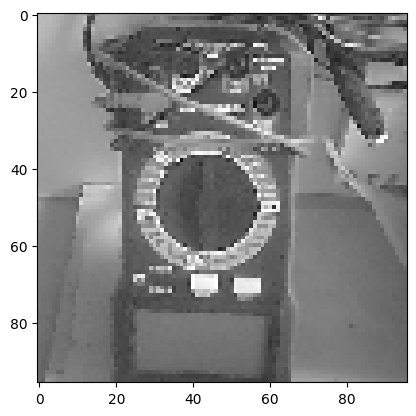

In [3]:

image = np.zeros((96,96))
d=0
for y in range(0,96):
  for x in range(0,96):
    image[y,x] = HEXADECIMAL_BYTES[y*96+x]
print(image)
plt.imshow(image, cmap='gray', vmin=0, vmax=np.max(image))
plt.show()